<a href="https://colab.research.google.com/github/gpicciuca/ai_engineering_master/blob/main/module9_rl_cybersecurity/Project_Cybersecurity_for_healthcare_with_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Cybersecurity for healthcare with Reinforcement Learning
Master in AI Engineering @ Profession.AI <br>
Course: Reinforcement Learning <br>
Student: Giuseppe Picciuca

The goal of this project is to train and evaluate how a RL Agent performs in a task such as Cybersecurity: fighting off hackers from accessing the system, by strengthening weak nodes and/or trying to detect the intruder in time and blocking it. <br><br>

In the next sections we'll be setting up and comparing 3 different algorithms in 2 different environments: <br>
- Q-Learning, used as a baseline on RandomAttack
- SARSA, also on RandomAttack, directly compared to Q-Learning
- Double DQN, evaluated on RandomAttack and MaximalAttack

<br>
Let's start by setting up all needed dependencies to get our environment working:

In [ ]:
!pip install swig
!pip install git+https://github.com/Limmen/gym-idsgame.git
!pip install gymnasium[box2d]
!pip install gymnasium[classic-control]

Install support for LaTeX, required for plotting ExperimentResults via matplotlib:

In [ ]:
!sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended

Patch the Gymnasium package by pulling missing files and useful utilities from their repository:

In [ ]:
!wget "https://raw.githubusercontent.com/openai/gym/refs/tags/0.22.0/gym/utils/atomic_write.py" -P "/usr/local/lib/python3.11/dist-packages/gym/utils/"
!wget "https://raw.githubusercontent.com/openai/gym/refs/tags/0.22.0/gym/utils/closer.py" -P "/usr/local/lib/python3.11/dist-packages/gym/utils/"
!wget "https://raw.githubusercontent.com/openai/gym/refs/tags/0.22.0/gym/utils/json_utils.py" -P "/usr/local/lib/python3.11/dist-packages/gym/utils/"
!touch "/usr/local/lib/python3.11/dist-packages/gym_idsgame/experiments/util/__init__.py"
!wget "https://raw.githubusercontent.com/Limmen/gym-idsgame/refs/heads/test/experiments/util/util.py" -P "/usr/local/lib/python3.11/dist-packages/gym_idsgame/experiments/util/"
!wget "https://raw.githubusercontent.com/Limmen/gym-idsgame/refs/heads/test/experiments/util/plotting_util.py" -P "/usr/local/lib/python3.11/dist-packages/gym_idsgame/experiments/util/"

And add a missing include in the gym_idsgame files...

In [4]:
!echo "from gym_idsgame.envs.util import idsgame_util" >> /usr/local/lib/python3.11/dist-packages/gym_idsgame/agents/bot_agents/random_attack_bot_agent.py

From here on, we start with the actual implementation of this notebook:

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image

import gymnasium as gym
import gym_idsgame
from gym_idsgame.envs import IdsGameEnv, IdsGameRandomAttackV8Env, IdsGameMaximalAttackV8Env
from gym_idsgame.envs.dao.idsgame_config import IdsGameConfig
from gym_idsgame.agents.dao.experiment_result import ExperimentResult
from gym_idsgame.agents.training_agents.q_learning.q_agent import QAgent, QAgentConfig
from gym_idsgame.agents.training_agents.q_learning.tabular_q_learning.tabular_q_agent import TabularQAgent
from gym_idsgame.agents.training_agents.q_learning.dqn.dqn_config import DQNConfig

from gym_idsgame.experiments.util import plotting_util
from gym_idsgame.experiments.util import util

/usr/local/lib/python3.11/dist-packages/gym_idsgame/experiments/util/plotting_util.py:42: DeprecationWarning: invalid escape sequence '\#'
  ax[0][0].set_xlabel("Episode \#")
/usr/local/lib/python3.11/dist-packages/gym_idsgame/experiments/util/plotting_util.py:133: DeprecationWarning: invalid escape sequence '\m'
  ax[1][0].set_ylabel("$\mathbb{P}[Hacked]$")


In [6]:
RANDOM_SEED = 35

# Compatibility wrappers
Due to version mismatches, gym_idsgame is no longer compatible with the latest Gym API. <br>
The classes below provide a simple workaround by bridging the different APIs and providing correct arguments and return values. <br><br>

Here we are using V8 of the environments as it's been found to work well out of the box, unlike the latest V21 which, in our tests, has not worked at all and led the same set of configurations (env + agent) to negative rewards consistently.

In [7]:
class IdsGameRandomAttackV8EnvFixed(IdsGameRandomAttackV8Env):
    def __init__(self, idsgame_config = None, save_dir: str = None, initial_state_path: str = None):
        super().__init__(idsgame_config, save_dir, initial_state_path)

    def step(self, actions):
        _, reward, terminated, truncated, info = super().step(actions)
        return self.get_observation(), reward, terminated or truncated, info

    def reset(self, *, seed: int | None = None, options: dict | None = None, update_stats = False):
        super().reset(seed=seed, update_stats=update_stats)
        return self.get_observation()

class IdsGameMaximalAttackV8EnvFixed(IdsGameMaximalAttackV8Env):
    def __init__(self, idsgame_config = None, save_dir: str = None, initial_state_path: str = None):
        super().__init__(idsgame_config, save_dir, initial_state_path)

    def step(self, actions):
        _, reward, terminated, truncated, info = super().step(actions)
        return self.get_observation(), reward, terminated or truncated, info

    def reset(self, *, seed: int | None = None, options: dict | None = None, update_stats = False):
        super().reset(seed=seed, update_stats=update_stats)
        return self.get_observation()

# Utility methods
Useful methods needed throughout the codebase.

In [8]:
class Artefact:
    TRAINING = "train"
    TABLE = "table"
    PLOTS = "plots"

class Algorithm:
    QLEARNING = "qlearning"
    SARSA = "sarsa"
    DDQN = "ddqn"

class EnvType:
    RANDOM = "random"
    MAXIMAL = "maximal"

def create_artefact_dirs(algo_name : Algorithm, env_type : EnvType, artefact_type : Artefact):
    output_dir = f"./output/{algo_name}/{artefact_type}"
    os.makedirs(output_dir, exist_ok=True)
    return output_dir

In [9]:
def plot_image_pairs(base_dir, image_files, figsize=(12, 6)):
    """
    Plot images in pairs (2 images per row) from a list of file paths.

    Args:
        base_dir (str): Base directory path
        image_paths (list): List of image file paths in desired order
        figsize (tuple): Figure size for each row (width, height)
    """
    # Calculate number of rows needed
    num_rows = (len(image_files) + 1) // 2

    # Create subplots with reduced spacing
    fig, axes = plt.subplots(num_rows, 2, figsize=figsize)
    fig.subplots_adjust(hspace=0.3, wspace=0.1)

    # Plot images in pairs
    for i, img_path in enumerate(image_files):
        row = i // 2
        col = i % 2

        # Load and display image
        img = Image.open(os.path.join(base_dir, img_path))

        axes[row, col].imshow(img)
        axes[row, col].set_title(os.path.basename(img_path), fontsize=10)
        axes[row, col].axis('off')

    # Hide empty subplot if odd number of images
    if len(image_files) % 2 == 1:
        axes[-1, -1].axis('off')

    plt.tight_layout()
    plt.show()

In [10]:
def plot_experiment(algorithm : Algorithm, env_type : EnvType, config : QAgentConfig, experiment_results : ExperimentResult, eval : bool = True, figsize=(12, 6)):
    """
    Plot the results of an experiment.

    Args:
        algorithm (str): Algorithm used (SARSA, QLEARNING, ...)
        env_type (str): Environment used (RandomAttack, MaximalAttack, ...)
        config (QAgentConfig): Agent configuration
        experiment_results (ExperimentResult): Results to plot
        eval (bool): Whether to plot evaluation or training results
        figsize (tuple): Figure size
    """
    output_dir_prefix = f"./output/{algorithm}/{env_type}"
    output_dir = f"{output_dir_prefix}/results/plots/0"
    os.makedirs(output_dir, exist_ok=True)
    print(f"Reading from {output_dir}")

    # Plot and save experiment results to images on disk
    plotting_util.plot_results(
        avg_attacker_episode_rewards=experiment_results.avg_attacker_episode_rewards,
        avg_defender_episode_rewards=experiment_results.avg_defender_episode_rewards,
        avg_episode_steps=experiment_results.avg_episode_steps,
        epsilon_values=experiment_results.epsilon_values,
        hack_probability=experiment_results.hack_probability,
        attacker_cumulative_reward=experiment_results.attacker_cumulative_reward,
        defender_cumulative_reward=experiment_results.defender_cumulative_reward,
        avg_episode_loss_attacker=experiment_results.avg_episode_loss_attacker,
        avg_episode_loss_defender=experiment_results.avg_episode_loss_defender,
        learning_rate_values=experiment_results.lr_list,
        log_frequency=config.eval_log_frequency,
        eval_frequency=config.eval_frequency,
        eval_episodes=config.eval_episodes,
        output_dir=output_dir_prefix,
        eval=eval,
    )

    # Load and plot previously generated plots
    suffix = "eval" if eval else "train"
    plot_image_pairs(output_dir, image_files=[
        f"avg_attacker_episode_returns_{suffix}.png",
        f"avg_defender_episode_returns_{suffix}.png",
        f"attacker_cumulative_reward_{suffix}.png",
        f"defender_cumulative_reward_{suffix}.png",
        f"avg_episode_loss_attacker_{suffix}.png",
        f"avg_episode_loss_defender_{suffix}.png",
        f"avg_episode_lengths_{suffix}.png",
        f"epsilon_{suffix}.png",
        f"hack_probability_{suffix}.png",
        f"lr_{suffix}.png",
    ], figsize=figsize)

# Baseline Q-Learning Agent on RandomAttack
Evaluate how the baseline Q-Learning implementation performs on RandomAttack. <br>
This will be useful later to compare SARSA and/or DDQN to get an idea of how the different algorithms perform on the given task.

## Environment setup and training

In [129]:
# Define and create folders where the training artefacts should be stored
qlearning_output = {
    Artefact.TRAINING: create_artefact_dirs(Algorithm.QLEARNING, EnvType.RANDOM, Artefact.TRAINING),
    Artefact.TABLE: create_artefact_dirs(Algorithm.QLEARNING, EnvType.RANDOM, Artefact.TABLE),
    Artefact.PLOTS: create_artefact_dirs(Algorithm.QLEARNING, EnvType.RANDOM, Artefact.PLOTS),
}

# Instantiate the environment
qlearning_env = IdsGameRandomAttackV8EnvFixed(None, save_dir=qlearning_output[Artefact.TRAINING])

# Configuration
qlearning_config = QAgentConfig(
    gamma=0.99,               # Discount factor
    alpha=0.001,              # Learning rate
    epsilon=1,                # Initial exploration rate
    min_epsilon=0.1,          # Minimum exploration rate
    epsilon_decay=0.999,      # Decay rate per episode

    # Training parameters
    num_episodes=20000,
    train_log_frequency=1000,
    eval_log_frequency=500,
    eval_frequency=1000,
    eval_episodes=1000,

    # Agent type
    attacker=False,
    defender=True,            # Sets this agent as Defender

    # Logging e savings
    save_dir=qlearning_output[Artefact.TABLE]
)

# Create and train the agent
qlearning_agent = TabularQAgent(qlearning_env, qlearning_config)
qlearning_agent.train()

[Train] episode: 0.00 epsilon:1.00,avg_a_R:-1.00,avg_d_R:1.00,avg_t:5.00,avg_h:0.00,acc_A_R:0.00,acc_D_R:0.00,A_loss:0.000000,D_loss:0.000000,replay_s:-1,lr:1.00E-03,c_h:0.00:   0%|          | 0/20000 [00:00<?, ?it/s]
Eval Episode:   0%|          | 0/1000 [00:00<?, ?it/s]
[Eval] avg_a_R:0.00,avg_d_R:0.00,avg_t:0.00,avg_h:0.00,acc_A_R:0.00,acc_D_R:0.00:   0%|          | 0/1000 [00:00<?, ?it/s]
[Train] episode: 19900.00 epsilon:0.01,avg_a_R:0.16,avg_d_R:0.43,avg_t:4.57,avg_h:0.19,acc_A_R:2231.25,acc_D_R:9383.00,A_loss:0.000000,D_loss:0.000000,replay_s:-1,lr:1.00E-03,c_h:0.18: 100%|██████████| 20000/20000 [15:50<00:00, 21.05it/s] 
[Eval] avg_a_R:0.00,avg_d_R:0.00,avg_t:0.00,avg_h:0.00,acc_A_R:0.00,acc_D_R:0.00: 100%|██████████| 100/100 [13:16<00:00,  7.96s/it] 

[Eval] episode:0,avg_a_R:-1.00,avg_d_R:1.00,avg_t:5.00,avg_h:0.00,acc_A_R:-1.00,acc_D_R:1.00,replay_s:-1,lr:0.00E+00,c_h:0.00:   2%|▏         | 18/1000 [00:00<00:05, 176.03it/s]
[Eval] episode:0,avg_a_R:-1.00,avg_d_R:1.00,avg_t:5.

## Results
Q-Learning is already performing really well on RandomAttack, outperforming the hacker consistently. The defender is yielding much higher rewards compared to the attacker, indicating that overall the defender manages to catch and block the hacker. <br><br>

However, the attacker still manages to penetrate the defender's system 10% of the time (hack probability), so there's still room for improvement.

Reading from ./output/qlearning/results/plots/0



[Train] episode: 19000.00 epsilon:0.10,avg_a_R:-0.36,avg_d_R:0.74,avg_t:3.02,avg_h:0.09,acc_A_R:-5809.73,acc_D_R:13332.00,A_loss:0.000000,D_loss:0.000000,replay_s:-1,lr:1.00E-03,c_h:0.10: 100%|██████████| 20000/20000 [02:16<00:00, 233.74it/s]

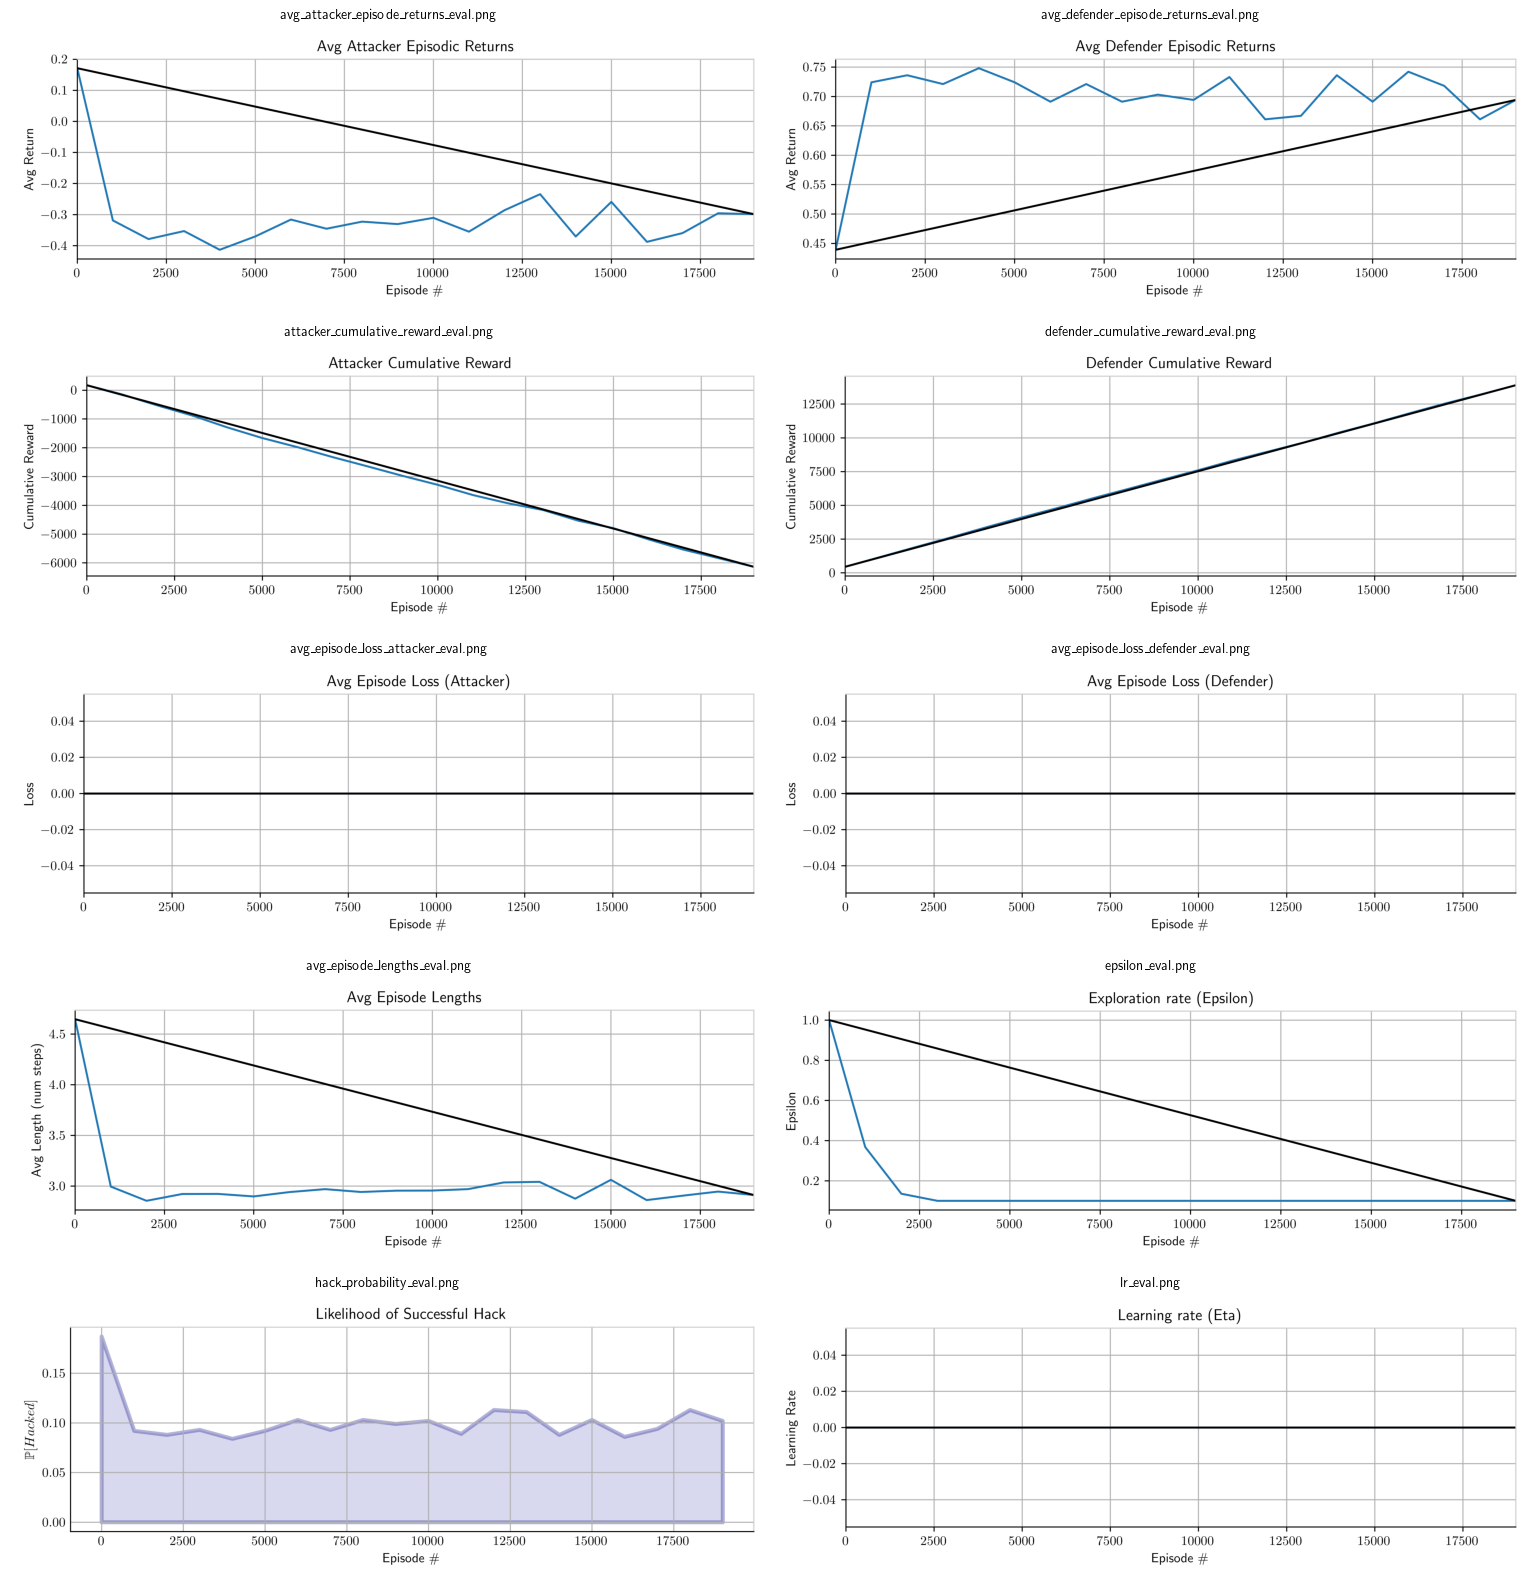

In [130]:
plot_experiment(Algorithm.QLEARNING, qlearning_config, qlearning_agent.eval_result, figsize=(16, 16))

# SARSA Agent on RandomAttack
The SARSA-based Agent evaluated on the RandomAttack environment. <br>
The implementation is an adaptation of the existing TabularQAgent class from gym_idsgame.

## SARSA Agent implementation
The implementation is entirely based off of gym_idsgame's own TabularQAgent implementation with some adjustments to integrate the on-policy SARSA algo.

In [124]:
"""
An agent for the IDSGameEnv that implements the SARSA algorithm.
"""
from typing import Union
import numpy as np
import time
import tqdm
import os
from gym_idsgame.envs.rendering.video.idsgame_monitor import IdsGameMonitor
from gym_idsgame.agents.training_agents.q_learning.q_agent_config import QAgentConfig
from gym_idsgame.envs.idsgame_env import IdsGameEnv
from gym_idsgame.agents.dao.experiment_result import ExperimentResult
from gym_idsgame.agents.training_agents.q_learning.q_agent import QAgent

class SARSAAgent(QAgent):

    def __init__(self, env:IdsGameEnv, config: QAgentConfig):
        """
        Initialize environment and hyperparameters

        :param config: the configuration
        """
        super(SARSAAgent, self).__init__(env, config)
        if not self.config.tab_full_state_space:
            self.Q_attacker = np.zeros((self.env.num_states, self.env.num_attack_actions))
            self.Q_defender = np.zeros((1, self.env.num_defense_actions))
        else:
            self.Q_attacker = np.zeros((self.env.num_states_full, self.env.num_attack_actions))
            self.Q_defender = np.zeros((self.env.num_states_full, self.env.num_defense_actions))
            if self.env.num_states_full < 10000:
                self.state_to_idx = self.env._build_state_to_idx_map()
                self.max_value = np.array(list(map(lambda x: list(x), self.state_to_idx.keys()))).flatten().max()

        self.env.idsgame_config.save_trajectories = False
        self.env.idsgame_config.save_attack_stats = True

    def get_action(self, s, eval=False, attacker=True) -> int:
        """
        Sample an action using an epsilon-greedy policy with respect to the current Q-values

        :param s: the state to sample an action for
        :param eval: whether sampling an action in eval mode (greedy without exploration)
        :param attacker: if true, sample action from attacker, else use defender
        :return: a sampled action
        """
        if attacker:
            actions = list(range(self.env.num_attack_actions))
            legal_actions = list(filter(lambda action: self.env.is_attack_legal(action), actions))
        else:
            actions = list(range(self.env.num_defense_actions))
            legal_actions = list(filter(lambda action: self.env.is_defense_legal(action), actions))
        if (np.random.rand() < self.config.epsilon and not eval) \
                or (eval and np.random.random() < self.config.eval_epsilon):
            return np.random.choice(legal_actions)
        max_legal_action_value = float("-inf")
        max_legal_action = float("-inf")
        if attacker:
            for i in range(len(self.Q_attacker[s])):
                if i in legal_actions and self.Q_attacker[s][i] > max_legal_action_value:
                    max_legal_action_value = self.Q_attacker[s][i]
                    max_legal_action = i
        else:
            for i in range(len(self.Q_defender[s])):
                if i in legal_actions and self.Q_defender[s][i] > max_legal_action_value:
                    max_legal_action_value = self.Q_defender[s][i]
                    max_legal_action = i
        if max_legal_action == float("-inf") or max_legal_action_value == float("-inf"):
            raise AssertionError("Error when selecting action greedily according to the Q-function")
        return max_legal_action

    def choose_action(self, attacker_obs, defender_obs) -> Union[int, int]:
        # Default initialization
        s_idx_a = 0
        defender_state_node_id = 0
        s_idx_d = defender_state_node_id
        attacker_action = 0
        defender_action = 0

        # Get attacker and defender actions
        if self.config.attacker:
            s_idx_a = self.env.get_attacker_node_from_observation(attacker_obs)
            if self.config.tab_full_state_space:
                if self.env.fully_observed():
                    attacker_obs = np.append(attacker_obs, defender_obs)
                t = tuple(attacker_obs.astype(int).flatten().tolist())
                t = tuple(map(lambda x: min(x, self.max_value), t))
                s_idx_a = self.state_to_idx[t]
            attacker_action = self.get_action(s_idx_a, attacker=True)

        if self.config.defender:
            s_idx_d = defender_state_node_id
            if self.config.tab_full_state_space:
                if self.env.fully_observed():
                    defender_obs = np.append(attacker_obs, defender_obs)
                t = tuple(defender_obs.astype(int).flatten().tolist())
                t = tuple(map(lambda x: min(x, self.max_value), t))
                s_idx_d = self.state_to_idx[t]
            defender_action = self.get_action(s_idx_d, attacker=False)

        action = (attacker_action, defender_action)
        return action, s_idx_a, s_idx_d

    def train(self) -> ExperimentResult:
        """
        Runs the SARSA algorithm

        :return: Experiment result
        """
        self.config.logger.info("Starting Training")
        self.config.logger.info(self.config.to_str())
        if len(self.train_result.avg_episode_steps) > 0:
            self.config.logger.warning("starting training with non-empty result object")

        # Start clean on the very first run
        attacker_obs, defender_obs = self.env.reset(update_stats=False)

        # Tracking metrics
        episode_attacker_rewards = []
        episode_defender_rewards = []
        episode_steps = []

        # Logging
        self.outer_train.set_description_str("[Train] epsilon:{:.2f},avg_a_R:{:.2f},avg_d_R:{:.2f},"
                                             "avg_t:{:.2f},avg_h:{:.2f},acc_A_R:{:.2f}," \
                                             "acc_D_R:{:.2f}".format(self.config.epsilon, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0))

        # Training
        for episode in range(self.config.num_episodes):
            episode_attacker_reward = 0
            episode_defender_reward = 0
            episode_step = 0

            action, s_idx_a, s_idx_d = self.choose_action(attacker_obs, defender_obs)

            done = False
            while not done:
                if self.config.render:
                    self.env.render(mode="human")

                if not self.config.attacker and not self.config.defender:
                    raise AssertionError("Must specify whether training an attacker agent or defender agent")

                # Take a step in the environment
                next_action, reward, obs_prime, done = self.step_and_update(action, s_idx_a, s_idx_d)

                # Update state information and metrics
                attacker_reward, defender_reward = reward
                obs_prime_attacker, obs_prime_defender = obs_prime
                episode_attacker_reward += attacker_reward
                episode_defender_reward += defender_reward
                episode_step += 1
                attacker_obs = obs_prime_attacker
                defender_obs = obs_prime_defender
                action = next_action

            # Render final frame
            if self.config.render:
                self.env.render(mode="human")

            # Record episode metrics
            self.num_train_games += 1
            self.num_train_games_total += 1
            if self.env.state.hacked:
                self.num_train_hacks += 1
                self.num_train_hacks_total += 1
            episode_attacker_rewards.append(episode_attacker_reward)
            episode_defender_rewards.append(episode_defender_reward)
            episode_steps.append(episode_step)

            # Log average metrics every <self.config.train_log_frequency> episodes
            if episode % self.config.train_log_frequency == 0:
                if self.num_train_games > 0 and self.num_train_games_total > 0:
                    self.train_hack_probability = self.num_train_hacks / self.num_train_games
                    self.train_cumulative_hack_probability = self.num_train_hacks_total / self.num_train_games_total
                else:
                    self.train_hack_probability = 0.0
                    self.train_cumulative_hack_probability = 0.0
                self.log_metrics(episode, self.train_result, episode_attacker_rewards, episode_defender_rewards,
                                 episode_steps, None, None, lr=self.config.alpha)
                episode_attacker_rewards = []
                episode_defender_rewards = []
                episode_steps = []
                self.num_train_games = 0
                self.num_train_hacks = 0

            # Run evaluation every <self.config.eval_frequency> episodes
            if episode % self.config.eval_frequency == 0:
                self.eval(episode)

            # Save Q table every <self.config.checkpoint_frequency> episodes
            if episode % self.config.checkpoint_freq == 0:
                self.save_q_table()
                self.env.save_trajectories(checkpoint = True)
                self.env.save_attack_data(checkpoint = True)
                if self.config.save_dir is not None:
                    time_str = str(time.time())
                    self.train_result.to_csv(self.config.save_dir + "/" + time_str + "_train_results_checkpoint.csv")
                    self.eval_result.to_csv(self.config.save_dir + "/" + time_str + "_eval_results_checkpoint.csv")

            # Reset environment for the next episode and update game stats
            attacker_obs, defender_obs = self.env.reset(update_stats=True)
            self.outer_train.update(1)

            # Anneal epsilon linearly
            self.anneal_epsilon()

        self.config.logger.info("Training Complete")

        # Final evaluation (for saving Gifs etc)
        self.eval(self.config.num_episodes, log=False)

        # Log and return
        self.log_state_values()

        # Save Q Table
        self.save_q_table()

        # Save other game data
        self.env.save_trajectories(checkpoint = False)
        self.env.save_attack_data(checkpoint = False)
        if self.config.save_dir is not None:
            time_str = str(time.time())
            self.train_result.to_csv(self.config.save_dir + "/" + time_str + "_train_results_checkpoint.csv")
            self.eval_result.to_csv(self.config.save_dir + "/" + time_str + "_eval_results_checkpoint.csv")

        return self.train_result

    def step_and_update(self, action, s_idx_a, defender_state_node_id, eval=False) -> Union[float, np.ndarray, bool]:
        obs_prime, reward, done, info = self.env.step(action)
        attacker_reward, defender_reward = reward
        attacker_obs_prime, defender_obs_prime = obs_prime
        attacker_action, defender_action = action

        (next_attacker_action, next_defender_action), next_s_idx_a, next_s_idx_d = self.choose_action(attacker_obs_prime, defender_obs_prime)

        if self.config.attacker:
            s_prime_idx = self.env.get_attacker_node_from_observation(attacker_obs_prime)
            if self.config.tab_full_state_space:
                if self.env.fully_observed():
                    attacker_obs_prime = np.append(attacker_obs_prime, defender_obs_prime)
                t = tuple(attacker_obs_prime.astype(int).flatten().tolist())
                t = tuple(map(lambda x: min(x, self.max_value), t))
                s_prime_idx = self.state_to_idx[t]

            if not eval:
                self.sarsa_update(s_idx_a, attacker_action, next_attacker_action, attacker_reward, s_prime_idx, attacker=True)

        if self.config.defender:
            s_prime_idx = 0
            if self.config.tab_full_state_space:
                if self.env.fully_observed():
                    defender_obs_prime = np.append(attacker_obs_prime, defender_obs_prime)
                t = tuple(defender_obs_prime.astype(int).flatten().tolist())
                t = tuple(map(lambda x: min(x, self.max_value), t))
                s_prime_idx = self.state_to_idx[t]

            if not eval:
                self.sarsa_update(defender_state_node_id, defender_action, next_defender_action, defender_reward, s_prime_idx, attacker=False)

        return (next_attacker_action, next_defender_action), reward, obs_prime, done

    def sarsa_update(self, s : int, a : int, next_a : int, r : float, s_prime : int, attacker=True) -> None:
        """
        Performs a sarsa update

        :param s: the state i
        :param a: the action id
        :param next_a: the next action id
        :param r: the reward
        :param s_prime: the result state id
        :param attacker: boolean flag, if True update attacker Q, otherwise update defender Q
        :return: None
        """
        if attacker:
            self.Q_attacker[s][a] = self.Q_attacker[s][a] + self.config.alpha * (r + self.config.gamma * self.Q_attacker[s_prime][next_a] - self.Q_attacker[s][a])
        else:
            self.Q_defender[s][a] = self.Q_defender[s][a] + self.config.alpha * (r + self.config.gamma * self.Q_defender[s_prime][next_a] - self.Q_defender[s][a])

    def eval(self, train_episode, log=True) -> ExperimentResult:
        """
        Performs evaluation with the greedy policy with respect to the learned Q-values

        :param log: whether to log the result
        :param train_episode: train episode to keep track of logs and plots
        :return: None
        """
        self.config.logger.info("Starting Evaluation")
        time_str = str(time.time())

        self.num_eval_games = 0
        self.num_eval_hacks = 0

        if len(self.eval_result.avg_episode_steps) > 0:
            self.config.logger.warning("starting eval with non-empty result object")
        if self.config.eval_episodes < 1:
            return
        done = False

        # Video config
        if self.config.video:
            if self.config.video_dir is None:
                raise AssertionError("Video is set to True but no video_dir is provided, please specify "
                                     "the video_dir argument")
            self.env = IdsGameMonitor(self.env, self.config.video_dir + "/" + time_str, force=True,
                                      video_frequency=self.config.video_frequency)
            self.env.metadata["video.frames_per_second"] = self.config.video_fps

        # Tracking metrics
        episode_attacker_rewards = []
        episode_defender_rewards = []
        episode_steps = []

        # Logging
        self.outer_eval = tqdm.tqdm(total=self.config.eval_episodes, desc='Eval Episode', position=1)
        self.outer_eval.set_description_str(
            "[Eval] avg_a_R:{:.2f},avg_d_R:{:.2f},avg_t:{:.2f},avg_h:{:.2f},acc_A_R:{:.2f}," \
            "acc_D_R:{:.2f}".format(0.0, 0,0, 0.0, 0.0, 0.0, 0.0))

        # Eval
        attacker_obs, defender_obs = self.env.reset(update_stats=False)

        # Get initial frame
        if self.config.video or self.config.gifs:
            initial_frame = self.env.render(mode="rgb_array")[0]
            self.env.episode_frames.append(initial_frame)

        for episode in range(self.config.eval_episodes):
            episode_attacker_reward = 0
            episode_defender_reward = 0
            episode_step = 0
            attacker_state_values = []
            attacker_states = []
            attacker_frames = []
            defender_state_values = []
            defender_states = []
            defender_frames = []

            if self.config.video or self.config.gifs:
                attacker_state_node_id = self.env.get_attacker_node_from_observation(attacker_obs)
                attacker_state_values.append(sum(self.Q_attacker[attacker_state_node_id]))
                attacker_states.append(attacker_state_node_id)
                attacker_frames.append(initial_frame)
                defender_state_node_id = 0
                defender_state_values.append(sum(self.Q_defender[defender_state_node_id]))
                defender_states.append(defender_state_node_id)
                defender_frames.append(initial_frame)

            while not done:
                if self.config.eval_render:
                    self.env.render()
                    time.sleep(self.config.eval_sleep)

                # Default initialization
                attacker_state_node_id = 0
                defender_state_node_id = 0
                attacker_action = 0
                defender_action = 0

                # Get attacker and defender actions
                if self.config.attacker:
                    s_idx_a = self.env.get_attacker_node_from_observation(attacker_obs)
                    if self.config.tab_full_state_space:
                        if self.env.fully_observed():
                            attacker_obs = np.append(attacker_obs, defender_obs)
                        t = tuple(attacker_obs.astype(int).flatten().tolist())
                        t = tuple(map(lambda x: min(x, self.max_value), t))
                        s_idx_a = self.state_to_idx[t]
                    attacker_action = self.get_action(s_idx_a, attacker=True, eval=True)

                if self.config.defender:
                    s_idx_d = defender_state_node_id
                    if self.config.tab_full_state_space:
                        if self.env.fully_observed():
                            defender_obs = np.append(attacker_obs, defender_obs)
                        t = tuple(defender_obs.astype(int).flatten().tolist())
                        t = tuple(map(lambda x: min(x, self.max_value), t))
                        s_idx_d = self.state_to_idx[t]
                    defender_action = self.get_action(s_idx_d, attacker=False, eval=True)

                action = (attacker_action, defender_action)

                # Take a step in the environment
                obs_prime, reward, done, _ = self.env.step(action)

                # Update state information and metrics
                attacker_reward, defender_reward = reward
                obs_prime_attacker, obs_prime_defender = obs_prime
                episode_attacker_reward += attacker_reward
                episode_defender_reward += defender_reward
                episode_step += 1
                attacker_obs = obs_prime_attacker
                defender_obs = obs_prime_defender

                # Save state values for analysis later
                if self.config.video and len(self.env.episode_frames) > 1:
                    if self.config.attacker:
                        attacker_state_node_id = self.env.get_attacker_node_from_observation(attacker_obs)
                        attacker_state_values.append(sum(self.Q_attacker[attacker_state_node_id]))
                        attacker_states.append(attacker_state_node_id)
                        attacker_frames.append(self.env.episode_frames[-1])

                    if self.config.defender:
                        defender_state_node_id = 0
                        defender_state_values.append(sum(self.Q_defender[defender_state_node_id]))
                        defender_states.append(defender_state_node_id)
                        defender_frames.append(self.env.episode_frames[-1])

            # Render final frame when game completed
            if self.config.eval_render:
                self.env.render()
                time.sleep(self.config.eval_sleep)
            self.config.logger.info("Eval episode: {}, Game ended after {} steps".format(episode, episode_step))

            # Record episode metrics
            episode_attacker_rewards.append(episode_attacker_reward)
            episode_defender_rewards.append(episode_defender_reward)
            episode_steps.append(episode_step)

            # Update eval stats
            self.num_eval_games +=1
            self.num_eval_games_total += 1
            self.eval_attacker_cumulative_reward += episode_attacker_reward
            self.eval_defender_cumulative_reward += episode_defender_reward
            if self.env.state.hacked:
                self.num_eval_hacks += 1
                self.num_eval_hacks_total += 1

            # Log average metrics every <self.config.eval_log_frequency> episodes
            if episode % self.config.eval_log_frequency == 0 and log:
                if self.num_eval_games > 0:
                    self.eval_hack_probability = float(self.num_eval_hacks) / float(self.num_eval_games)
                if self.num_eval_games_total > 0:
                    self.eval_cumulative_hack_probability = float(self.num_eval_hacks_total) / float(
                        self.num_eval_games_total)
                self.log_metrics(episode, self.eval_result, episode_attacker_rewards, episode_defender_rewards,
                                 episode_steps, update_stats=False, eval = True)

            # Save gifs
            if self.config.gifs and self.config.video:
                self.env.generate_gif(self.config.gif_dir + "/episode_" + str(train_episode) + "_"
                                      + time_str + ".gif", self.config.video_fps)

            if len(attacker_frames) > 1:
                # Save state values analysis for final state
                base_path = self.config.save_dir + "/state_values/" + str(train_episode) + "/"
                if not os.path.exists(base_path):
                    os.makedirs(base_path)
                np.save(base_path + "attacker_states.npy", attacker_states)
                np.save(base_path + "attacker_state_values.npy", attacker_state_values)
                np.save(base_path + "attacker_frames.npy", attacker_frames)


            if len(defender_frames) > 1:
                # Save state values analysis for final state
                base_path = self.config.save_dir + "/state_values/" + str(train_episode) + "/"
                if not os.path.exists(base_path):
                    os.makedirs(base_path)
                np.save(base_path + "defender_states.npy", np.array(defender_states))
                np.save(base_path + "defender_state_values.npy", np.array(defender_state_values))
                np.save(base_path + "defender_frames.npy", np.array(defender_frames))

            # Reset for new eval episode
            done = False
            attacker_obs, defender_obs = self.env.reset(update_stats=False)
            # Get initial frame
            if self.config.video or self.config.gifs:
                initial_frame = self.env.render(mode="rgb_array")[0]
                self.env.episode_frames.append(initial_frame)

            self.outer_eval.update(1)

        # Log average eval statistics
        if log:
            if self.num_eval_games > 0:
                self.eval_hack_probability = float(self.num_eval_hacks) / float(self.num_eval_games)
            if self.num_eval_games_total > 0:
                self.eval_cumulative_hack_probability = float(self.num_eval_hacks_total) / float(self.num_eval_games_total)
            self.log_metrics(train_episode, self.eval_result, episode_attacker_rewards, episode_defender_rewards,
                             episode_steps, update_stats=True, eval=True)

        self.env.close()
        self.config.logger.info("Evaluation Complete")
        return self.eval_result

    def log_state_values(self) -> None:
        """
        Utility function for printing the state-values according to the learned Q-function

        :return: None
        """
        if self.config.attacker:
            self.config.logger.info("--- Attacker State Values ---")
            for i in range(len(self.Q_attacker)):
                state_value = sum(self.Q_attacker[i])
                node_id = i
                self.config.logger.info("s:{},V(s):{}".format(node_id, state_value))
            self.config.logger.info("--------------------")

        if self.config.defender:
            self.config.logger.info("--- Defender State Values ---")
            for i in range(len(self.Q_defender)):
                state_value = sum(self.Q_defender[i])
                node_id = i
                self.config.logger.info("s:{},V(s):{}".format(node_id, state_value))
            self.config.logger.info("--------------------")

    def save_q_table(self) -> None:
        """
        Saves Q table to disk in binary npy format

        :return: None
        """
        time_str = str(time.time())
        if self.config.save_dir is not None:
            if self.config.attacker:
                path = self.config.save_dir + "/" + time_str + "_attacker_q_table.npy"
                self.config.logger.info("Saving Q-table to: {}".format(path))
                np.save(path, self.Q_attacker)
            if self.config.defender:
                path = self.config.save_dir + "/" + time_str + "_defender_q_table.npy"
                self.config.logger.info("Saving Q-table to: {}".format(path))
                np.save(path, self.Q_defender)
        else:
            self.config.logger.warning("Save path not defined, not saving Q table to disk")


## Environment setup and training
Prepares and runs the SARSA Agent in the RandomAttack environment. <br>
The structure follows the same pattern as for the baseline scenario, with some very small tweaks to the hyperparameters. Episodes and evaluation frequencies are identical.

In [133]:
sarsa_output = {
    Artefact.TRAINING: create_artefact_dirs(Algorithm.SARSA, EnvType.RANDOM, Artefact.TRAINING),
    Artefact.TABLE: create_artefact_dirs(Algorithm.SARSA, EnvType.RANDOM, Artefact.TABLE),
    Artefact.PLOTS: create_artefact_dirs(Algorithm.SARSA, EnvType.RANDOM, Artefact.PLOTS),
}

sarsa_env = IdsGameRandomAttackV8EnvFixed(None, save_dir=sarsa_output[Artefact.TRAINING])

sarsa_config = QAgentConfig(
    gamma=0.98,               # Discount factor
    alpha=0.002,              # Learning rate
    epsilon=1,                # Initial exploration rate
    min_epsilon=0.1,          # Minimum exploration rate
    epsilon_decay=0.99925,      # Decay rate per episode

    # Training parameters
    num_episodes=20000,
    train_log_frequency=1000,
    eval_log_frequency=500,
    eval_frequency=1000,
    eval_episodes=1000,

    # Agent type
    attacker=False,
    defender=True,            # Sets this agent as Defender

    # Logging e savings
    save_dir=sarsa_output[Artefact.TABLE]
)

sarsa_agent = SARSAAgent(sarsa_env, sarsa_config)
sarsa_agent.train()

[Train] episode: 0.00 epsilon:1.00,avg_a_R:0.25,avg_d_R:1.00,avg_t:6.00,avg_h:0.00,acc_A_R:0.00,acc_D_R:0.00,A_loss:0.000000,D_loss:0.000000,replay_s:-1,lr:2.00E-03,c_h:0.00:   0%|          | 0/20000 [00:00<?, ?it/s]
Eval Episode:   0%|          | 0/1000 [00:00<?, ?it/s]
[Eval] avg_a_R:0.00,avg_d_R:0.00,avg_t:0.00,avg_h:0.00,acc_A_R:0.00,acc_D_R:0.00:   0%|          | 0/1000 [00:00<?, ?it/s]
[Eval] episode:0,avg_a_R:-1.00,avg_d_R:1.00,avg_t:4.00,avg_h:0.00,acc_A_R:-1.00,acc_D_R:1.00,replay_s:-1,lr:0.00E+00,c_h:0.00:   0%|          | 0/1000 [00:00<?, ?it/s]
[Eval] episode:0,avg_a_R:-1.00,avg_d_R:1.00,avg_t:4.00,avg_h:0.00,acc_A_R:-1.00,acc_D_R:1.00,replay_s:-1,lr:0.00E+00,c_h:0.00:   3%|▎         | 27/1000 [00:00<00:03, 258.98it/s]
[Train] episode: 19000.00 epsilon:0.15,avg_a_R:0.03,avg_d_R:0.54,avg_t:4.64,avg_h:0.15,acc_A_R:480.76,acc_D_R:10314.00,A_loss:0.000000,D_loss:0.000000,replay_s:-1,lr:2.00E-03,c_h:0.15: 100%|██████████| 20000/20000 [04:46<00:00, 69.80it/s] 
[Eval] avg_a_R:0.00

## Results
From the plots below, it seems like SARSA is not performing as well as the baseline QLearning algorithm on RandomAttack. <br>
The attacker manages to stay in the positive range of rewards, even though the defender still vastly outperforms the attacker. <br>
However, the hack probability remains twice as high for SARSA than it was for QLearning (15-20% for SARSA vs ~10% for QLearning).

Reading from ./output/sarsa/results/plots/0


[Train] episode: 19000.00 epsilon:0.10,avg_a_R:0.12,avg_d_R:0.48,avg_t:5.03,avg_h:0.17,acc_A_R:1676.19,acc_D_R:9261.00,A_loss:0.000000,D_loss:0.000000,replay_s:-1,lr:2.00E-03,c_h:0.17: 100%|██████████| 20000/20000 [03:30<00:00, 196.54it/s]
[Eval] avg_a_R:0.00,avg_d_R:0.00,avg_t:0.00,avg_h:0.00,acc_A_R:0.00,acc_D_R:0.00: 100%|██████████| 1000/1000 [00:21<00:00, 205.45it/s]

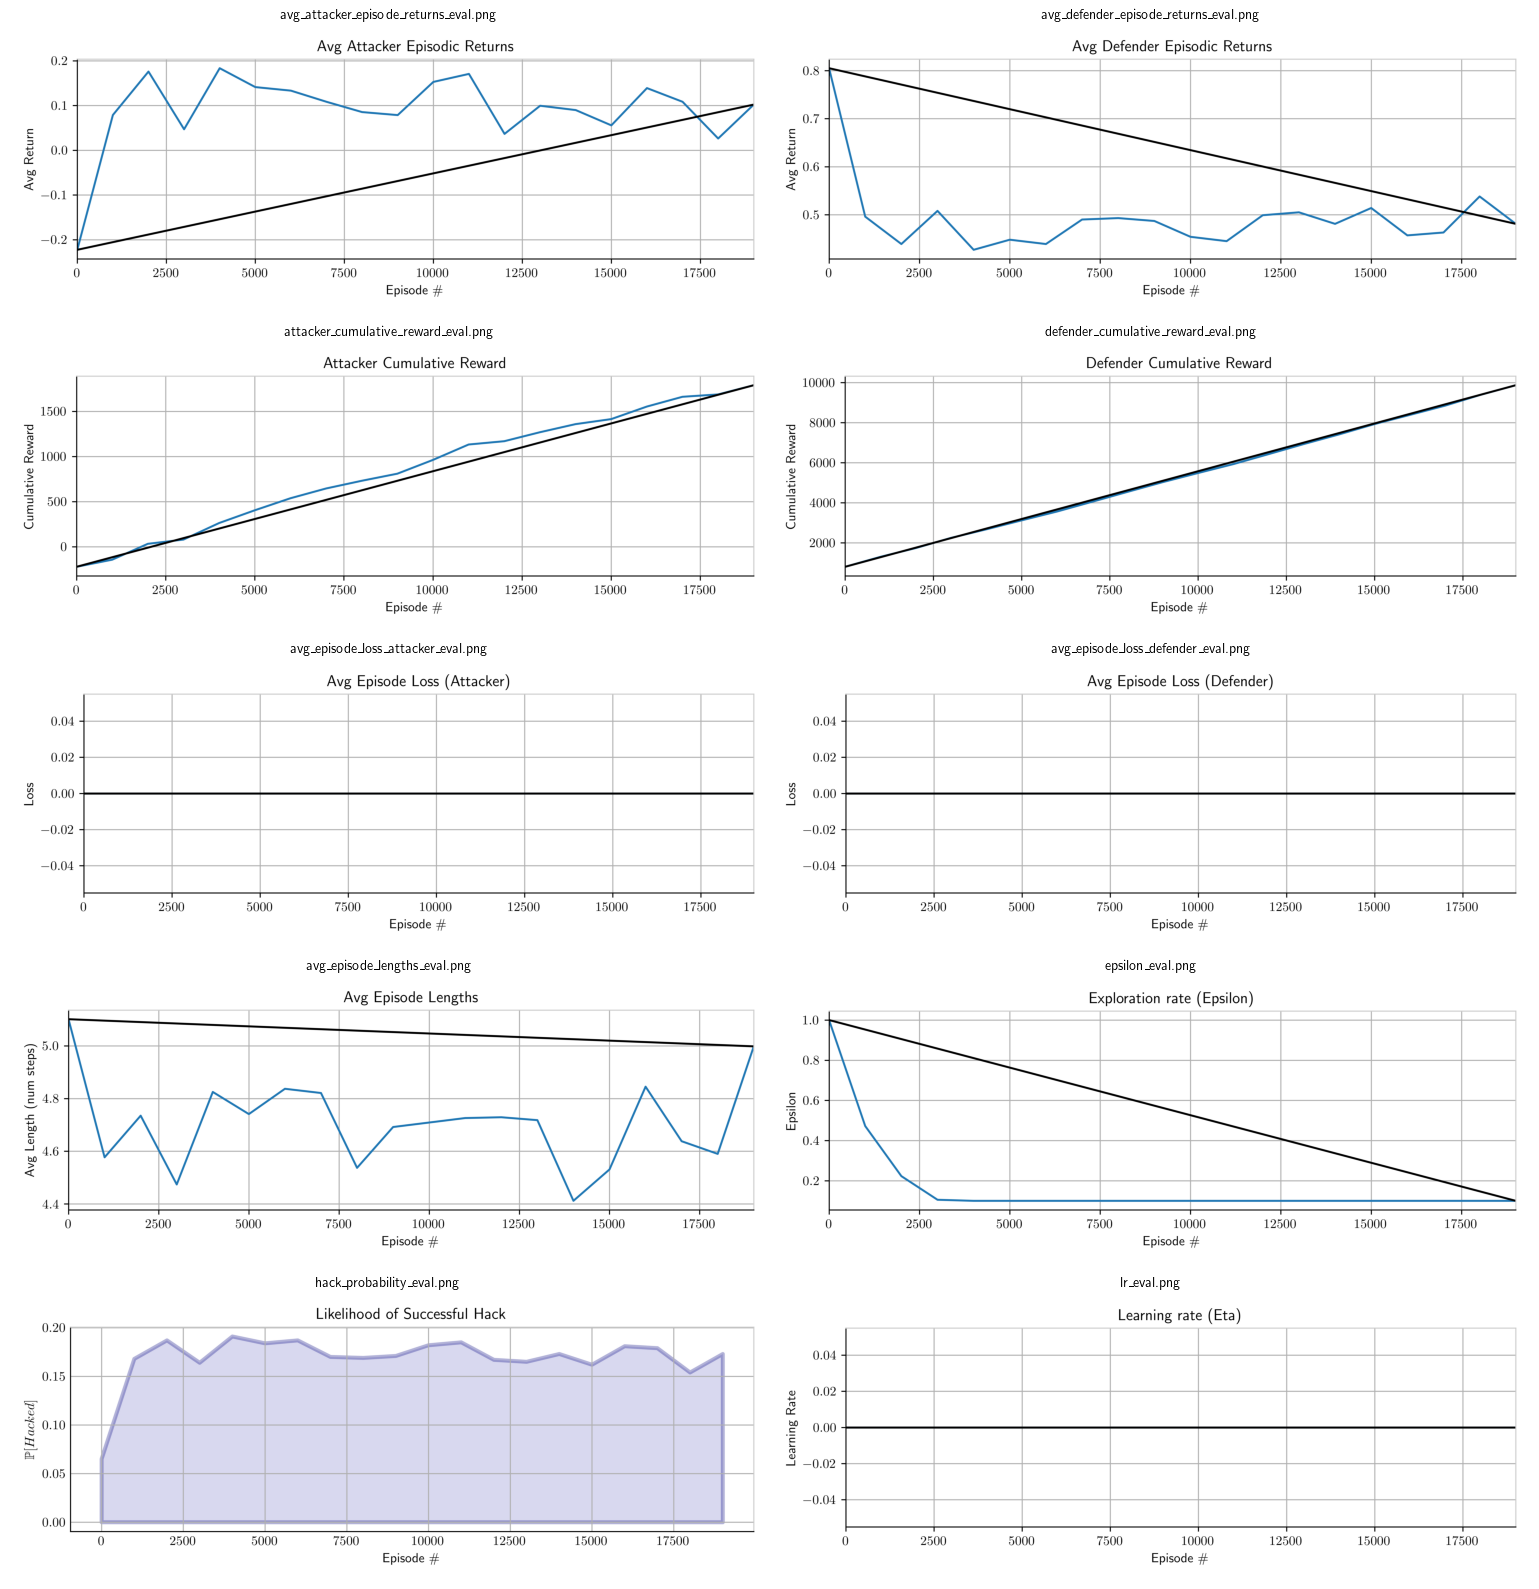

In [134]:
plot_experiment(Algorithm.SARSA, EnvType.RANDOM, sarsa_config, sarsa_agent.eval_result, figsize=(16, 16))

# DDQN Agent on RandomAttack and MaximalAttack

## DDQN Agent Implementation
This implementation is an adaptation of the DQN algorithm from gym_idsgame. <br>
The class already came with most of the required logic out of the box, e.g. target network update every X episodes. <br>
Only the `training_step` method required some adjustments to integrate the Double DQN loss calculation.

In [11]:
"""
An agent for the IDSGameEnv that implements the DQN algorithm.
"""
from typing import Union
import numpy as np
import time
import tqdm
import torch
from torch.utils.tensorboard import SummaryWriter
from gym_idsgame.envs.rendering.video.idsgame_monitor import IdsGameMonitor
from gym_idsgame.agents.training_agents.q_learning.q_agent_config import QAgentConfig
from gym_idsgame.envs.idsgame_env import IdsGameEnv
from gym_idsgame.agents.dao.experiment_result import ExperimentResult
from gym_idsgame.envs.constants import constants
from gym_idsgame.agents.training_agents.models.fnn_w_linear import FNNwithLinear
from gym_idsgame.agents.training_agents.q_learning.experience_replay.replay_buffer import ReplayBuffer
from gym_idsgame.agents.training_agents.q_learning.q_agent import QAgent

class DDQNAgent(QAgent):
    """
    An implementation of the DQN algorithm from the paper 'Human-level control through deep reinforcement learning' by
    Mnih et. al.

    (DQN is originally Neural-fitted Q-iteration but with the addition of a separate target network)
    """
    def __init__(self, env:IdsGameEnv, config: QAgentConfig):
        """
        Initialize environment and hyperparameters

        :param config: the configuration
        """
        super(DDQNAgent, self).__init__(env, config)
        self.attacker_q_network = None
        self.attacker_target_network = None
        self.defender_q_network = None
        self.defender_target_network = None
        self.loss_fn = None
        self.attacker_optimizer = None
        self.defender_optimizer = None
        self.attacker_lr_decay = None
        self.defender_lr_decay = None
        self.tensorboard_writer = SummaryWriter(self.config.dqn_config.tensorboard_dir)
        self.buffer = ReplayBuffer(config.dqn_config.replay_memory_size)
        self.initialize_models()
        self.tensorboard_writer.add_hparams(self.config.hparams_dict(), {})
        self.env.idsgame_config.save_trajectories = False
        self.env.idsgame_config.save_attack_stats = False

    def warmup(self) -> None:
        """
        A warmup without any learning just to populate the replay buffer following a random strategy

        :return: None
        """

        # Setup logging
        outer_warmup = tqdm.tqdm(total=self.config.dqn_config.replay_start_size, desc='Warmup', position=0)
        outer_warmup.set_description_str("[Warmup] step:{}, buffer_size: {}".format(0, 0))

        # Reset env
        obs = self.env.reset(update_stats=False)
        attacker_obs, defender_obs = obs
        obs_state_a = self.update_state(attacker_obs, defender_obs, attacker=True, state=[])
        obs_state_d = self.update_state(attacker_obs, defender_obs, attacker=False, state=[])
        obs = (obs_state_a, obs_state_d)
        self.config.logger.info("Starting warmup phase to fill replay buffer")

        # Perform <self.config.dqn_config.replay_start_size> steps and fill the replay memory
        for i in range(self.config.dqn_config.replay_start_size):

            if i % self.config.train_log_frequency == 0:
                log_str = "[Warmup] step:{}, buffer_size: {}".format(i, self.buffer.size())
                outer_warmup.set_description_str(log_str)
                self.config.logger.info(log_str)

            # Select random attacker and defender actions
            attacker_actions = list(range(self.env.num_attack_actions))
            defender_actions = list(range(self.env.num_defense_actions))
            legal_attack_actions = list(filter(lambda action: self.env.is_attack_legal(action), attacker_actions))
            legal_defense_actions = list(filter(lambda action: self.env.is_defense_legal(action), defender_actions))
            attacker_action = np.random.choice(legal_attack_actions)
            defender_action = np.random.choice(legal_defense_actions)
            action = (attacker_action, defender_action)

            # Take action in the environment
            obs_prime, reward, done, info = self.env.step(action)
            attacker_obs_prime, defender_obs_prime = obs_prime
            obs_state_a_prime = self.update_state(attacker_obs_prime, defender_obs_prime, attacker=True, state=[])
            obs_state_d_prime = self.update_state(attacker_obs_prime, defender_obs_prime, attacker=False, state=[])
            obs_prime = (obs_state_a_prime, obs_state_d_prime)

            # Add transition to replay memory
            self.buffer.add_tuple(obs, action, reward, done, obs_prime)

            # Move to new state
            obs = obs_prime
            outer_warmup.update(1)

            if done:
                obs = self.env.reset(update_stats=False)
                attacker_obs, defender_obs = obs
                obs_state_a = self.update_state(attacker_obs, defender_obs, attacker=True, state=[])
                obs_state_d = self.update_state(attacker_obs, defender_obs, attacker=False, state=[])
                obs = (obs_state_a, obs_state_d)

        self.config.logger.info("{} Warmup steps completed, replay buffer size: {}".format(
            self.config.dqn_config.replay_start_size, self.buffer.size()))
        self.env.close()

        try:
            # Add network graph to tensorboard with a sample batch as input
            mini_batch = self.buffer.sample(self.config.dqn_config.batch_size)
            s_attacker_batch, s_defender_batch, a_attacker_batch, a_defender_batch, r_attacker_batch, r_defender_batch, \
            d_batch, s2_attacker_batch, s2_defender_batch = mini_batch

            if self.config.attacker:
                s_1 = torch.tensor(s_attacker_batch).float()
                # Move to GPU if using GPU
                if torch.cuda.is_available() and self.config.dqn_config.gpu:
                    device = torch.device("cuda:0")
                    s_1 = s_1.to(device)

                self.tensorboard_writer.add_graph(self.attacker_q_network, s_1)

            if self.config.defender:

                s_1 = torch.tensor(s_defender_batch).float()
                # Move to GPU if using GPU
                if torch.cuda.is_available() and self.config.dqn_config.gpu:
                    device = torch.device("cuda:0")
                    s_1 = s_1.to(device)

                self.tensorboard_writer.add_graph(self.defender_q_network, s_1)
        except:
            self.config.logger.warning("Error when trying to add network graph to tensorboard")

    def initialize_models(self) -> None:
        """
        Initialize models
        :return: None
        """

        # Initialize models
        self.attacker_q_network = FNNwithLinear(self.config.dqn_config.input_dim, self.config.dqn_config.attacker_output_dim,
                                                self.config.dqn_config.hidden_dim,
                                                num_hidden_layers=self.config.dqn_config.num_hidden_layers,
                                                hidden_activation=self.config.dqn_config.hidden_activation)
        self.attacker_target_network = FNNwithLinear(self.config.dqn_config.input_dim, self.config.dqn_config.attacker_output_dim,
                                                     self.config.dqn_config.hidden_dim,
                                                     num_hidden_layers=self.config.dqn_config.num_hidden_layers,
                                                     hidden_activation=self.config.dqn_config.hidden_activation)
        self.defender_q_network = FNNwithLinear(self.config.dqn_config.input_dim, self.config.dqn_config.defender_output_dim,
                                                self.config.dqn_config.hidden_dim,
                                                num_hidden_layers=self.config.dqn_config.num_hidden_layers,
                                                hidden_activation=self.config.dqn_config.hidden_activation)
        self.defender_target_network = FNNwithLinear(self.config.dqn_config.input_dim, self.config.dqn_config.defender_output_dim,
                                                     self.config.dqn_config.hidden_dim,
                                                     num_hidden_layers=self.config.dqn_config.num_hidden_layers,
                                                     hidden_activation=self.config.dqn_config.hidden_activation)

        # Specify device
        if torch.cuda.is_available() and self.config.dqn_config.gpu:
            device = torch.device("cuda:0")
            self.config.logger.info("Running on the GPU")
        else:
            device = torch.device("cpu")
            self.config.logger.info("Running on the CPU")

        self.attacker_q_network.to(device)
        self.attacker_target_network.to(device)
        self.defender_q_network.to(device)
        self.defender_target_network.to(device)

        # Set the target network to use the same weights initialization as the q-network
        self.attacker_target_network.load_state_dict(self.attacker_q_network.state_dict())
        self.defender_target_network.load_state_dict(self.defender_q_network.state_dict())
        # The target network is not trainable it is only used for predictions, therefore we set it to eval mode
        # to turn of dropouts, batch norms, gradient computations etc.
        self.attacker_target_network.eval()
        self.defender_target_network.eval()

        # Construct loss function
        if self.config.dqn_config.loss_fn == "MSE":
            self.loss_fn = torch.nn.MSELoss()
        elif self.config.dqn_config.loss_fn == "Huber":
            self.loss_fn = torch.nn.SmoothL1Loss()
        else:
            raise ValueError("Loss function not recognized")

        # Define Optimizer. The call to model.parameters() in the optimizer constructor will contain the learnable
        # parameters of the layers in the model
        if self.config.dqn_config.optimizer == "Adam":
            self.attacker_optimizer = torch.optim.Adam(self.attacker_q_network.parameters(), lr=self.config.alpha)
            self.defender_optimizer = torch.optim.Adam(self.defender_q_network.parameters(), lr=self.config.alpha)
        elif self.config.dqn_config.optimizer == "SGD":
            self.attacker_optimizer = torch.optim.SGD(self.attacker_q_network.parameters(), lr=self.config.alpha)
            self.defender_optimizer = torch.optim.SGD(self.defender_q_network.parameters(), lr=self.config.alpha)
        else:
            raise ValueError("Optimizer not recognized")

        # LR decay
        if self.config.dqn_config.lr_exp_decay:
            self.attacker_lr_decay = torch.optim.lr_scheduler.ExponentialLR(optimizer=self.attacker_optimizer,
                                                                       gamma=self.config.dqn_config.lr_decay_rate)
            self.defender_lr_decay = torch.optim.lr_scheduler.ExponentialLR(optimizer=self.attacker_optimizer,
                                                                            gamma=self.config.dqn_config.lr_decay_rate)


    def training_step(self,
                      mini_batch: Union[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray,
                                        np.ndarray, np.ndarray, np.ndarray], attacker: bool = True) -> torch.Tensor:
        """
        Performs a training step of the Deep-Q-learning algorithm (implemented in PyTorch)

        :param mini_batch: a minibatch to use for the training step
        :param attacker: whether doing a training step for the attacker (otherwise defender)
        :return: loss
        """

        # Unpack batch of transitions from the replay memory
        s_attacker_batch, s_defender_batch, a_attacker_batch, a_defender_batch, r_attacker_batch, r_defender_batch, \
        d_batch, s2_attacker_batch, s2_defender_batch = mini_batch

        # Convert batch into torch tensors and set Q-network in train mode and target network in eval mode
        if attacker:
            self.attacker_q_network.train()
            self.attacker_target_network.eval()
            r_1 = torch.tensor(r_attacker_batch).float()
            s_1 = torch.tensor(s_attacker_batch).float()
            s_2 = torch.tensor(s2_attacker_batch).float()
        else:
            self.defender_q_network.train()
            self.defender_q_network.eval()
            r_1 = torch.tensor(r_defender_batch).float()
            s_1 = torch.tensor(s_defender_batch).float()
            s_2 = torch.tensor(s2_defender_batch).float()

        # Move to GPU if using GPU
        if torch.cuda.is_available() and self.config.dqn_config.gpu:
            device = torch.device("cuda:0")
            r_1 = r_1.to(device)
            s_1 = s_1.to(device)
            s_2 = s_2.to(device)

        # Set target baseline. We only want the loss to be computed for the Q-values of the actions taken, not the entire
        # vector of all Q-values. Therefore we initialize the target to the Q-values of the Q-network for s
        # and then we only update the Q-values for the affected actions with the real targets
        if attacker:
            target = self.attacker_q_network(s_1)
        else:
            target = self.defender_q_network(s_1)

        ####################################################################
        ####################################################################
        ## DDQN UPDATE
        ####################################################################
        # Use the target network to compute the Q-values of s'
        with torch.no_grad():
            if attacker:
                next_action = torch.argmax(self.attacker_q_network(s_2), dim=1)
                target_next = self.attacker_target_network(s_2).detach()
            else:
                next_action = torch.argmax(self.defender_q_network(s_2), dim=1)
                target_next = self.defender_target_network(s_2).detach()

            target_next = target_next.gather(1, next_action.unsqueeze(1)).squeeze()
        ####################################################################
        ####################################################################

        for i in range(self.config.dqn_config.batch_size):
            # As defined by Mnih et. al. : For terminal states the Q-target should be equal to the immediate reward
            if d_batch[i]:
                if attacker:
                    target[i][a_attacker_batch[i]] = r_1[i]
                else:
                    target[i][a_defender_batch[i]] = r_1[i]

            # For non terminal states the Q-target should be the immediate reward plus the discounted estimated future
            # reward when following Q* estimated by the target network.
            else:
                if attacker:
                    target[i][a_attacker_batch[i]] = r_1[i] + self.config.gamma * target_next[i]
                else:
                    target[i][a_defender_batch[i]] = r_1[i] + self.config.gamma * target_next[i]

        # Compute loss
        if attacker:
            prediction = self.attacker_q_network(s_1)
        else:
            prediction = self.defender_q_network(s_1)

        loss = self.loss_fn(prediction, target)

        # Zero gradients, perform a backward pass, and update the weights.
        if attacker:
            self.attacker_optimizer.zero_grad()
            loss.backward()
            self.attacker_optimizer.step()
        else:
            self.defender_optimizer.zero_grad()
            loss.backward()
            self.defender_optimizer.step()

        return loss

    def get_action(self, state: np.ndarray, eval : bool = False, attacker : bool = True, use_greedy : bool = True) -> int:
        """
        Samples an action according to a epsilon-greedy strategy using the Q-network

        :param state: the state to sample an action for
        :param eval: boolean flag whether running in evaluation mode
        :param attacker: boolean flag whether running in attacker mode (if false assume defender)
        :param use_greedy: boolean flag whether to use greedy action selection
        :return: The sampled action id
        """
        state = torch.from_numpy(state.flatten()).float()

        # Move to GPU if using GPU
        if torch.cuda.is_available() and self.config.dqn_config.gpu:
            device = torch.device("cuda:0")
            state = state.to(device)

        if attacker:
            actions = list(range(self.env.num_attack_actions))
            legal_actions = list(filter(lambda action: self.env.is_attack_legal(action), actions))
        else:
            actions = list(range(self.env.num_defense_actions))
            legal_actions = list(filter(lambda action: self.env.is_defense_legal(action), actions))

        if use_greedy and ((np.random.rand() < self.config.epsilon and not eval) \
                or (eval and np.random.random() < self.config.eval_epsilon)):
            return np.random.choice(legal_actions)

        with torch.no_grad():
            if attacker:
                act_values = self.attacker_q_network(state)
            else:
                act_values = self.defender_q_network(state)

        return legal_actions[torch.argmax(act_values[legal_actions]).item()]

    def train(self) -> ExperimentResult:
        """
        Runs the DQN algorithm

        :return: Experiment result
        """
        self.config.logger.info("Starting Warmup")
        self.warmup()
        self.config.logger.info("Starting Training")
        self.config.logger.info(self.config.to_str())
        if len(self.train_result.avg_episode_steps) > 0:
            self.config.logger.warning("starting training with non-empty result object")
        done = False
        obs = self.env.reset(update_stats=False)
        attacker_obs, defender_obs = obs
        obs_state_a = self.update_state(attacker_obs, defender_obs, attacker=True, state=[])
        obs_state_d = self.update_state(attacker_obs, defender_obs, attacker=False, state=[])
        obs = (obs_state_a, obs_state_d)
        attacker_obs, defender_obs = obs

        # Tracking metrics
        episode_attacker_rewards = []
        episode_defender_rewards = []
        episode_steps = []
        episode_avg_attacker_loss = []
        episode_avg_defender_loss = []

        # Logging
        self.outer_train.set_description_str("[Train] epsilon:{:.2f},avg_a_R:{:.2f},avg_d_R:{:.2f},"
                                             "avg_t:{:.2f},avg_h:{:.2f},acc_A_R:{:.2f}," \
                                             "acc_D_R:{:.2f}".format(self.config.epsilon, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0))

        # Training
        for episode in range(self.config.num_episodes):
            episode_attacker_reward = 0
            episode_defender_reward = 0
            episode_step = 0
            episode_attacker_loss = 0.0
            episode_defender_loss = 0.0
            while not done:
                if self.config.render:
                    self.env.render(mode="human")

                if not self.config.attacker and not self.config.defender:
                    raise AssertionError("Must specify whether training an attacker agent or defender agent")

                # Default initialization
                attacker_action = 0
                defender_action = 0

                # Get attacker and defender actions
                if self.config.attacker:
                    attacker_action = self.get_action(attacker_obs, attacker=True)
                if self.config.defender:
                    defender_action = self.get_action(defender_obs, attacker=False)

                action = (attacker_action, defender_action)

                # Take a step in the environment
                obs_prime, reward, done, _ = self.env.step(action)
                attacker_obs_prime, defender_obs_prime = obs_prime
                obs_state_a_prime = self.update_state(attacker_obs_prime, defender_obs_prime, attacker=True, state=[])
                obs_state_d_prime = self.update_state(attacker_obs_prime, defender_obs_prime, attacker=False, state=[])
                obs_prime = (obs_state_a_prime, obs_state_d_prime)

                # Add transition to replay memory
                self.buffer.add_tuple(obs, action, reward, done, obs_prime)

                # Sample random mini_batch of transitions from replay memory
                minibatch = self.buffer.sample(self.config.dqn_config.batch_size)

                # Perform a gradient descent step of the Q-network using targets produced by target network
                if self.config.attacker:
                    loss = self.training_step(minibatch, attacker=True)
                    episode_attacker_loss += loss.item()

                if self.config.defender:
                    loss = self.training_step(minibatch, attacker=False)
                    episode_defender_loss += loss.item()


                # Update metrics
                attacker_reward, defender_reward = reward
                obs_prime_attacker, obs_prime_defender = obs_prime
                episode_attacker_reward += attacker_reward
                episode_defender_reward += defender_reward
                episode_step += 1

                # Move to the next state
                obs = obs_prime
                attacker_obs = obs_prime_attacker
                defender_obs = obs_prime_defender

            # Render final frame
            if self.config.render:
                self.env.render(mode="human")

            # Decay LR after every episode
            lr = self.config.alpha
            if self.config.dqn_config.lr_exp_decay:
                self.attacker_lr_decay.step()
                lr = self.attacker_lr_decay.get_lr()[0]

            # Record episode metrics
            self.num_train_games += 1
            self.num_train_games_total += 1
            if self.env.state.hacked:
                self.num_train_hacks += 1
                self.num_train_hacks_total += 1
            episode_attacker_rewards.append(episode_attacker_reward)
            episode_defender_rewards.append(episode_defender_reward)
            if episode_step > 0:
                if self.config.attacker:
                    episode_avg_attacker_loss.append(episode_attacker_loss/episode_step)
                if self.config.defender:
                    episode_avg_defender_loss.append(episode_defender_loss / episode_step)
            else:
                if self.config.attacker:
                    episode_avg_attacker_loss.append(episode_attacker_loss)
                if self.config.defender:
                    episode_avg_defender_loss.append(episode_defender_loss)

            episode_steps.append(episode_step)

            # Log average metrics every <self.config.train_log_frequency> episodes
            if episode % self.config.train_log_frequency == 0:
                if self.num_train_games > 0 and self.num_train_games_total > 0:
                    self.train_hack_probability = self.num_train_hacks / self.num_train_games
                    self.train_cumulative_hack_probability = self.num_train_hacks_total / self.num_train_games_total
                else:
                    self.train_hack_probability = 0.0
                    self.train_cumulative_hack_probability = 0.0
                self.log_metrics(episode, self.train_result, episode_attacker_rewards, episode_defender_rewards, episode_steps,
                                 episode_avg_attacker_loss, episode_avg_defender_loss, lr=lr)

                # Log values and gradients of the parameters (histogram summary) to tensorboard

                if self.config.attacker:
                    for tag, value in self.attacker_q_network.named_parameters():
                        tag = tag.replace('.', '/')
                        self.tensorboard_writer.add_histogram(tag, value.data.cpu().numpy(), episode)
                        self.tensorboard_writer.add_histogram(tag + '_attacker/grad', value.grad.data.cpu().numpy(),
                                                              episode)

                if self.config.defender:
                    for tag, value in self.defender_q_network.named_parameters():
                        tag = tag.replace('.', '/')
                        self.tensorboard_writer.add_histogram(tag, value.data.cpu().numpy(), episode)
                        self.tensorboard_writer.add_histogram(tag + '_defender/grad', value.grad.data.cpu().numpy(),
                                                              episode)

                episode_attacker_rewards = []
                episode_defender_rewards = []
                episode_steps = []
                self.num_train_games = 0
                self.num_train_hacks = 0

            # Update target network every <self.config.dqn_config.target_network_update_freq> episodes
            if episode % self.config.dqn_config.target_network_update_freq == 0:
                self.update_target_network()

            # Run evaluation every <self.config.eval_frequency> episodes
            if episode % self.config.eval_frequency == 0:
                self.eval(episode)

            # Save models every <self.config.checkpoint_frequency> episodes
            if episode % self.config.checkpoint_freq == 0:
                self.save_model()
                self.env.save_trajectories(checkpoint=True)
                self.env.save_attack_data(checkpoint=True)
                if self.config.save_dir is not None:
                    time_str = str(time.time())
                    self.train_result.to_csv(self.config.save_dir + "/" + time_str + "_train_results_checkpoint.csv")
                    self.eval_result.to_csv(self.config.save_dir + "/" + time_str + "_eval_results_checkpoint.csv")

            # Reset environment for the next episode and update game stats
            done = False
            obs = self.env.reset(update_stats=True)
            attacker_obs, defender_obs = obs
            obs_state_a = self.update_state(attacker_obs, defender_obs, attacker=True, state=[])
            obs_state_d = self.update_state(attacker_obs, defender_obs, attacker=False, state=[])
            obs = (obs_state_a, obs_state_d)
            attacker_obs, defender_obs = obs
            self.outer_train.update(1)

            # Anneal epsilon linearly
            self.anneal_epsilon()

        self.config.logger.info("Training Complete")

        # Final evaluation (for saving Gifs etc)
        self.eval(self.config.num_episodes-1, log=False)

        # Save Q-networks
        self.save_model()

        # Save other game data
        self.env.save_trajectories(checkpoint=False)
        self.env.save_attack_data(checkpoint=False)
        if self.config.save_dir is not None:
            time_str = str(time.time())
            self.train_result.to_csv(self.config.save_dir + "/" + time_str + "_train_results_checkpoint.csv")
            self.eval_result.to_csv(self.config.save_dir + "/" + time_str + "_eval_results_checkpoint.csv")

        return self.train_result

    def update_target_network(self) -> None:
        """
        Updates the target networks. Delayed targets are used to stabilize training and partially remedy the
        problem with non-stationary targets in RL with function approximation.

        :return: None
        """
        self.config.logger.info("Updating target network")

        if self.config.attacker:
            self.attacker_target_network.load_state_dict(self.attacker_q_network.state_dict())
            self.attacker_target_network.eval()

        if self.config.defender:
            self.defender_target_network.load_state_dict(self.defender_q_network.state_dict())
            self.defender_target_network.eval()

    def eval(self, train_episode, log=True) -> ExperimentResult:
        """
        Performs evaluation with the greedy policy with respect to the learned Q-values

        :param train_episode: the train episode to keep track of logging
        :param log: whether to log the result
        :return: None
        """
        self.config.logger.info("Starting Evaluation")
        time_str = str(time.time())

        self.num_eval_games = 0
        self.num_eval_hacks = 0

        if len(self.eval_result.avg_episode_steps) > 0:
            self.config.logger.warning("starting eval with non-empty result object")
        if self.config.eval_episodes < 1:
            return
        done = False

        # Video config
        if self.config.video:
            if self.config.video_dir is None:
                raise AssertionError("Video is set to True but no video_dir is provided, please specify "
                                     "the video_dir argument")
            self.env = IdsGameMonitor(self.env, self.config.video_dir + "/" + time_str, force=True,
                                      video_frequency=self.config.video_frequency)
            self.env.metadata["video.frames_per_second"] = self.config.video_fps

        # Tracking metrics
        episode_attacker_rewards = []
        episode_defender_rewards = []
        episode_steps = []

        # Logging
        self.outer_eval = tqdm.tqdm(total=self.config.eval_episodes, desc='Eval Episode', position=1)
        self.outer_eval.set_description_str(
            "[Eval] avg_a_R:{:.2f},avg_d_R:{:.2f},avg_t:{:.2f},avg_h:{:.2f},acc_A_R:{:.2f}," \
            "acc_D_R:{:.2f}".format(0.0, 0,0, 0.0, 0.0, 0.0, 0.0))

        # Eval
        obs = self.env.reset(update_stats=False)
        attacker_obs, defender_obs = obs
        obs_state_a = self.update_state(attacker_obs, defender_obs, attacker=True, state=[])
        obs_state_d = self.update_state(attacker_obs, defender_obs, attacker=False, state=[])
        obs = (obs_state_a, obs_state_d)
        attacker_obs, defender_obs = obs

        for episode in range(self.config.eval_episodes):
            episode_attacker_reward = 0
            episode_defender_reward = 0
            episode_step = 0
            while not done:
                if self.config.eval_render:
                    self.env.render()
                    time.sleep(self.config.eval_sleep)

                # Default initialization
                attacker_action = 0
                defender_action = 0

                # Get attacker and defender actions
                if self.config.attacker:
                    attacker_action = self.get_action(attacker_obs, eval=True, attacker=True)
                if self.config.defender:
                    defender_action = self.get_action(defender_obs, eval=True, attacker=False)
                action = (attacker_action, defender_action)

                # Take a step in the environment
                obs_prime, reward, done, _ = self.env.step(action)
                attacker_obs_prime, defender_obs_prime = obs_prime
                obs_state_a_prime = self.update_state(attacker_obs_prime, defender_obs_prime, attacker=True, state=[])
                obs_state_d_prime = self.update_state(attacker_obs_prime, defender_obs_prime, attacker=False, state=[])
                obs_prime = (obs_state_a_prime, obs_state_d_prime)

                # Update state information and metrics
                attacker_reward, defender_reward = reward
                obs_prime_attacker, obs_prime_defender = obs_prime
                episode_attacker_reward += attacker_reward
                episode_defender_reward += defender_reward
                episode_step += 1
                attacker_obs = obs_prime_attacker
                defender_obs = obs_prime_defender

            # Render final frame when game completed
            if self.config.eval_render:
                self.env.render()
                time.sleep(self.config.eval_sleep)
            self.config.logger.info("Eval episode: {}, Game ended after {} steps".format(episode, episode_step))

            # Record episode metrics
            episode_attacker_rewards.append(episode_attacker_reward)
            episode_defender_rewards.append(episode_defender_reward)
            episode_steps.append(episode_step)

            # Update eval stats
            self.num_eval_games +=1
            self.num_eval_games_total += 1
            if self.env.state.detected:
                self.eval_attacker_cumulative_reward -= constants.GAME_CONFIG.POSITIVE_REWARD
                self.eval_defender_cumulative_reward += constants.GAME_CONFIG.POSITIVE_REWARD
            if self.env.state.hacked:
                self.eval_attacker_cumulative_reward += constants.GAME_CONFIG.POSITIVE_REWARD
                self.eval_defender_cumulative_reward -= constants.GAME_CONFIG.POSITIVE_REWARD
                self.num_eval_hacks += 1
                self.num_eval_hacks_total +=1

            # Log average metrics every <self.config.eval_log_frequency> episodes
            if episode % self.config.eval_log_frequency == 0 and log:
                if self.num_eval_hacks > 0:
                    self.eval_hack_probability = float(self.num_eval_hacks) / float(self.num_eval_games)
                if self.num_eval_games_total > 0:
                    self.eval_cumulative_hack_probability = float(self.num_eval_hacks_total) / float(
                        self.num_eval_games_total)
                self.log_metrics(episode, self.eval_result, episode_attacker_rewards, episode_defender_rewards, episode_steps,
                                 eval = True, update_stats=False)

            # Save gifs
            if self.config.gifs and self.config.video:
                self.env.generate_gif(self.config.gif_dir + "/episode_" + str(train_episode) + "_"
                                      + time_str + ".gif", self.config.video_fps)

                # Add frames to tensorboard
                for idx, frame in enumerate(self.env.episode_frames):
                    self.tensorboard_writer.add_image(str(train_episode) + "_eval_frames/" + str(idx),
                                                       frame, global_step=train_episode,
                                                      dataformats = "HWC")


            # Reset for new eval episode
            done = False
            obs = self.env.reset(update_stats=False)
            attacker_obs, defender_obs = obs
            obs_state_a = self.update_state(attacker_obs, defender_obs, attacker=True, state=[])
            obs_state_d = self.update_state(attacker_obs, defender_obs, attacker=False, state=[])
            obs = (obs_state_a, obs_state_d)
            attacker_obs, defender_obs = obs
            self.outer_eval.update(1)

        # Log average eval statistics
        if log:
            if self.num_eval_hacks > 0:
                self.eval_hack_probability = float(self.num_eval_hacks) / float(self.num_eval_games)
            if self.num_eval_games_total > 0:
                self.eval_cumulative_hack_probability = float(self.num_eval_hacks_total) / float(
                    self.num_eval_games_total)

            self.log_metrics(train_episode, self.eval_result, episode_attacker_rewards, episode_defender_rewards,
                             episode_steps, eval=True, update_stats=True)

        self.env.close()
        self.config.logger.info("Evaluation Complete")
        return self.eval_result

    def save_model(self) -> None:
        """
        Saves the PyTorch Model Weights

        :return: None
        """
        time_str = str(time.time())
        if self.config.save_dir is not None:
            if self.config.attacker:
                path = self.config.save_dir + "/" + time_str + "_attacker_q_network.pt"
                self.config.logger.info("Saving Q-network to: {}".format(path))
                torch.save(self.attacker_q_network.state_dict(), path)
            if self.config.defender:
                path = self.config.save_dir + "/" + time_str + "_defender_q_network.pt"
                self.config.logger.info("Saving Q-network to: {}".format(path))
                torch.save(self.defender_q_network.state_dict(), path)
        else:
            self.config.logger.warning("Save path not defined, not saving Q-networks to disk")


    def update_state(self, attacker_obs: np.ndarray = None, defender_obs: np.ndarray = None,
                     state: np.ndarray = None, attacker: bool = True) -> np.ndarray:
        """
        Update approximative Markov state

        :param attacker_obs: attacker obs
        :param defender_obs: defender observation
        :param state: current state
        :param attacker: boolean flag whether it is attacker or not
        :return: new state
        """
        if attacker and self.env.idsgame_config.game_config.reconnaissance_actions:
            #if not self.env.local_view_features():
            a_obs_len = self.env.idsgame_config.game_config.num_attack_types + 1
            defender_obs = attacker_obs[:, a_obs_len:a_obs_len+self.env.idsgame_config.game_config.num_attack_types]
            if self.env.idsgame_config.reconnaissance_bool_features:
                d_bool_features = attacker_obs[:, a_obs_len+self.env.idsgame_config.game_config.num_attack_types:]
            attacker_obs = attacker_obs[:, 0:a_obs_len]
            # else:
            #     a_obs_len = self.env.idsgame_config.game_config.num_attack_types + 1
            #     defender_obs = attacker_obs[:,
            #                    a_obs_len:a_obs_len + self.env.idsgame_config.game_config.num_attack_types]
            #     if self.env.idsgame_config.reconnaissance_bool_features:
            #         d_bool_features = attacker_obs[:,
            #                           a_obs_len + self.env.idsgame_config.game_config.num_attack_types:]
            #     attacker_obs = attacker_obs[:, 0:a_obs_len]

        if not attacker and self.env.local_view_features():
            attacker_obs = self.env.state.get_attacker_observation(
                self.env.idsgame_config.game_config.network_config,
                local_view=False,
                reconnaissance=self.env.idsgame_config.reconnaissance_actions)


        # Zero mean
        if self.config.dqn_config.zero_mean_features:
            if not self.env.local_view_features() or not attacker:
                attacker_obs_1 = attacker_obs[:, 0:-1]
            else:
                attacker_obs_1 = attacker_obs[:, 0:-2]
            zero_mean_attacker_features = []
            for idx, row in enumerate(attacker_obs_1):
                mean = np.mean(row)
                if mean != 0:
                    t = row - mean
                else:
                    t = row
                if np.isnan(t).any():
                    t = attacker_obs[idx]
                else:
                    t = t.tolist()
                    if not self.env.local_view_features() or not attacker:
                        t.append(attacker_obs[idx][-1])
                    else:
                        t.append(attacker_obs[idx][-2])
                        t.append(attacker_obs[idx][-1])
                zero_mean_attacker_features.append(t)

            defender_obs_1 = defender_obs[:, 0:-1]
            zero_mean_defender_features = []
            for idx, row in enumerate(defender_obs_1):
                mean = np.mean(row)
                if mean != 0:
                    t = row - mean
                else:
                    t = row
                if np.isnan(t).any():
                    t = defender_obs[idx]
                else:
                    t = t.tolist()
                    t.append(defender_obs[idx][-1])
                zero_mean_defender_features.append(t)

            attacker_obs = np.array(zero_mean_attacker_features)
            defender_obs = np.array(zero_mean_defender_features)

        # Normalize
        if self.config.dqn_config.normalize_features:
            if not self.env.local_view_features() or not attacker:
                attacker_obs_1 = attacker_obs[:, 0:-1] / np.linalg.norm(attacker_obs[:, 0:-1])
            else:
                attacker_obs_1 = attacker_obs[:, 0:-2] / np.linalg.norm(attacker_obs[:, 0:-2])
            normalized_attacker_features = []
            for idx, row in enumerate(attacker_obs_1):
                if np.isnan(attacker_obs_1).any():
                    t = attacker_obs[idx]
                else:
                    t = row.tolist()
                    if not self.env.local_view_features() or not attacker:
                        t.append(attacker_obs[idx][-1])
                    else:
                        t.append(attacker_obs[idx][-2])
                        t.append(attacker_obs[idx][-1])
                normalized_attacker_features.append(t)

            if attacker and self.env.idsgame_config.game_config.reconnaissance_actions:
                defender_obs_1 = defender_obs[:, 0:-1] / np.linalg.norm(defender_obs[:, 0:-1])
            else:
                defender_obs_1 = defender_obs / np.linalg.norm(defender_obs)
            normalized_defender_features = []
            for idx, row in enumerate(defender_obs_1):
                if np.isnan(defender_obs_1).any():
                    t = defender_obs[idx]
                else:
                    if attacker and self.env.idsgame_config.game_config.reconnaissance_actions:
                        t = row.tolist()
                        t.append(defender_obs[idx][-1])
                    else:
                        t = row

                normalized_defender_features.append(t)

            attacker_obs = np.array(normalized_attacker_features)
            defender_obs = np.array(normalized_defender_features)

        if self.env.local_view_features() and attacker:
            if not self.env.idsgame_config.game_config.reconnaissance_actions:
                neighbor_defense_attributes = np.zeros((attacker_obs.shape[0], defender_obs.shape[1]))
                for node in range(attacker_obs.shape[0]):
                    id = int(attacker_obs[node][-1])
                    neighbor_defense_attributes[node] = defender_obs[id]
            else:
                neighbor_defense_attributes = defender_obs

        if self.env.fully_observed() or \
                (self.env.idsgame_config.game_config.reconnaissance_actions and attacker):
            if self.config.dqn_config.merged_ad_features:
                if not self.env.local_view_features() or not attacker:
                    a_pos = attacker_obs[:, -1]
                    if not self.env.idsgame_config.game_config.reconnaissance_actions:
                        det_values = defender_obs[:, -1]
                        temp = defender_obs[:, 0:-1] - attacker_obs[:, 0:-1]
                    else:
                        temp = defender_obs[:, 0:] - attacker_obs[:, 0:-1]
                    features = []
                    for idx, row in enumerate(temp):
                        t = row.tolist()
                        t.append(a_pos[idx])
                        if self.env.fully_observed():
                            t.append(det_values[idx])
                        features.append(t)
                else:
                    node_ids = attacker_obs[:, -1]
                    if not self.env.idsgame_config.game_config.reconnaissance_actions:
                        det_values = neighbor_defense_attributes[:, -1]
                    if not self.env.idsgame_config.game_config.reconnaissance_actions:
                        temp = neighbor_defense_attributes[:, 0:-1] - attacker_obs[:, 0:-1]
                    else:
                        temp = np.full(neighbor_defense_attributes.shape, -1)
                        for i in range(len(neighbor_defense_attributes)):
                            if np.sum(neighbor_defense_attributes[i]) > 0:
                                temp[i] = neighbor_defense_attributes[i] - attacker_obs[i, 0:-1]
                    features = []
                    for idx, row in enumerate(temp):
                        t = row.tolist()
                        t.append(node_ids[idx])
                        #t.append(node_reachable[idx])
                        if not self.env.idsgame_config.game_config.reconnaissance_actions:
                            t.append(det_values[idx])
                        features.append(t)
                features = np.array(features)
                if self.env.idsgame_config.reconnaissance_bool_features:
                    f = np.zeros((features.shape[0], features.shape[1] + d_bool_features.shape[1]))
                    for i in range(features.shape[0]):
                        f[i] = np.append(features[i], d_bool_features[i])
                    features = f
                if self.config.dqn_config.state_length == 1:
                    return features
                if len(state) == 0:
                    s = np.array([features] * self.config.dqn_config.state_length)
                    return s
                state = np.append(state[1:], np.array([features]), axis=0)
                return state
            else:
                if not self.env.local_view_features() or not attacker:
                    if self.env.idsgame_config.game_config.reconnaissance_actions and attacker:
                        combined_features = []
                        for idx, row in enumerate(attacker_obs):
                            combined_row = np.append(row, defender_obs[idx])
                            combined_features.append(combined_row)
                        if self.env.idsgame_config.reconnaissance_bool_features:
                            combined_features = np.array(combined_features)
                            f = np.zeros(
                                (combined_features.shape[0], combined_features.shape[1] + d_bool_features.shape[1]))
                            for i in range(combined_features.shape[0]):
                                f[i] = np.append(combined_features[i], d_bool_features[i])
                            combined_features = f
                        return np.array(combined_features)

                    return np.append(attacker_obs, defender_obs)
                else:
                    if self.env.idsgame_config.reconnaissance_bool_features:
                        f = np.zeros((attacker_obs.shape[0],
                                      attacker_obs.shape[1] + neighbor_defense_attributes.shape[1] +
                                      d_bool_features.shape[1]))
                        for i in range(f.shape[0]):
                            f[i] = np.append(np.append(attacker_obs[i], neighbor_defense_attributes[i]),
                                             d_bool_features[i])
                    else:
                        f = np.zeros((attacker_obs.shape[0],
                                      attacker_obs.shape[1] + neighbor_defense_attributes.shape[1]))
                        for i in range(f.shape[0]):
                            f[i] = np.append(attacker_obs[i], neighbor_defense_attributes[i])
                if self.config.dqn_config.state_length == 1:
                    return f
                if len(state) == 0:
                    s = np.array([f] * self.config.dqn_config.state_length)
                    return s
                # if not self.env.local_view_features() or not attacker:
                #     temp = np.append(attacker_obs, defender_obs)
                # else:
                #     temp = np.append(attacker_obs, neighbor_defense_attributes)
                state = np.append(state[1:], np.array([f]), axis=0)
            return state
        else:
            if self.config.dqn_config.state_length == 1:
                if attacker:
                    return np.array(attacker_obs)
                else:
                    return np.array(defender_obs)
            if len(state) == 0:
                if attacker:
                    return np.array([attacker_obs] * self.config.dqn_config.state_length)
                else:
                    return np.array([defender_obs] * self.config.dqn_config.state_length)
            if attacker:
                state = np.append(state[1:], np.array([attacker_obs]), axis=0)
            else:
                state = np.append(state[1:], np.array([defender_obs]), axis=0)
            return state

## DDQN Config
Stores a set of configuration parameters for the DDQN Model.

In [12]:
ddqn_config = DQNConfig(
    batch_size = 64,

    input_dim = 33,
    attacker_output_dim = 33,
    defender_output_dim = 33,
    hidden_dim = 256,
    num_hidden_layers = 3,

    target_network_update_freq = 100,
    gpu = torch.cuda.is_available(),

    loss_fn = "MSE",
    optimizer = "Adam",

    lr_exp_decay = True,
    lr_decay_rate = 0.9995,

    normalize_features = True,
    zero_mean_features = False,
    merged_ad_features = True,
)

## RandomAttack

### Environment setup and training
Configures and runs the RandomAttack environment on our DDQN Agent.

In [50]:
ddqn_ra_output = {
    Artefact.TRAINING: create_artefact_dirs(Algorithm.DDQN, EnvType.RANDOM, Artefact.TRAINING),
    Artefact.TABLE: create_artefact_dirs(Algorithm.DDQN, EnvType.RANDOM, Artefact.TABLE),
    Artefact.PLOTS: create_artefact_dirs(Algorithm.DDQN, EnvType.RANDOM, Artefact.PLOTS),
}

ddqn_ra_env = IdsGameRandomAttackV8EnvFixed(None, save_dir=ddqn_ra_output[Artefact.TRAINING])

ddqn_ra_config = QAgentConfig(
    gamma=0.98,               # Discount factor
    alpha=0.001,              # Learning rate
    epsilon=1,                # Initial exploration rate
    min_epsilon=0.1,          # Minimum exploration rate
    epsilon_decay=0.99925,      # Decay rate per episode

    # Training parameters
    num_episodes=20000,
    train_log_frequency=1000,
    eval_log_frequency=500,
    eval_frequency=1000,
    eval_episodes=1000,

    # Agent type
    attacker=False,
    defender=True,            # Sets this agent as Defender

    # Logging e savings
    save_dir=ddqn_ra_output[Artefact.TABLE],

    dqn_config = ddqn_config,
)

ddqn_ra_agent = DDQNAgent(ddqn_ra_env, ddqn_ra_config)
ddqn_ra_agent.train()

[Warmup] step:0, buffer_size: 0:   0%|          | 0/10000 [00:00<?, ?it/s]/tmp/ipython-input-48-3387873866.py:818: RuntimeWarning: invalid value encountered in divide
  attacker_obs_1 = attacker_obs[:, 0:-1] / np.linalg.norm(attacker_obs[:, 0:-1])
[Warmup] step:9000, buffer_size: 9000: 100%|██████████| 10000/10000 [00:12<00:00, 832.90it/s]
[Train] epsilon:1.00,avg_a_R:0.00,avg_d_R:0.00,avg_t:0.00,avg_h:0.00,acc_A_R:0.00,acc_D_R:0.00:   0%|          | 0/20000 [00:12<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/t

### Results
From the plots below, DDQN on RandomAttack seems to be the clear winner, with the defender hitting more than 15k rewards while the attacker hits lower than -15k! <br>
Hack probability is also less than 10%, lower than what we got with the baseline QLearning.

Reading from ./output/ddqn/random/results/plots/0



[Eval] avg_a_R:0.00,avg_d_R:0.00,avg_t:0.00,avg_h:0.00,acc_A_R:0.00,acc_D_R:0.00: 100%|██████████| 1000/1000 [00:20<00:00, 130.61it/s]

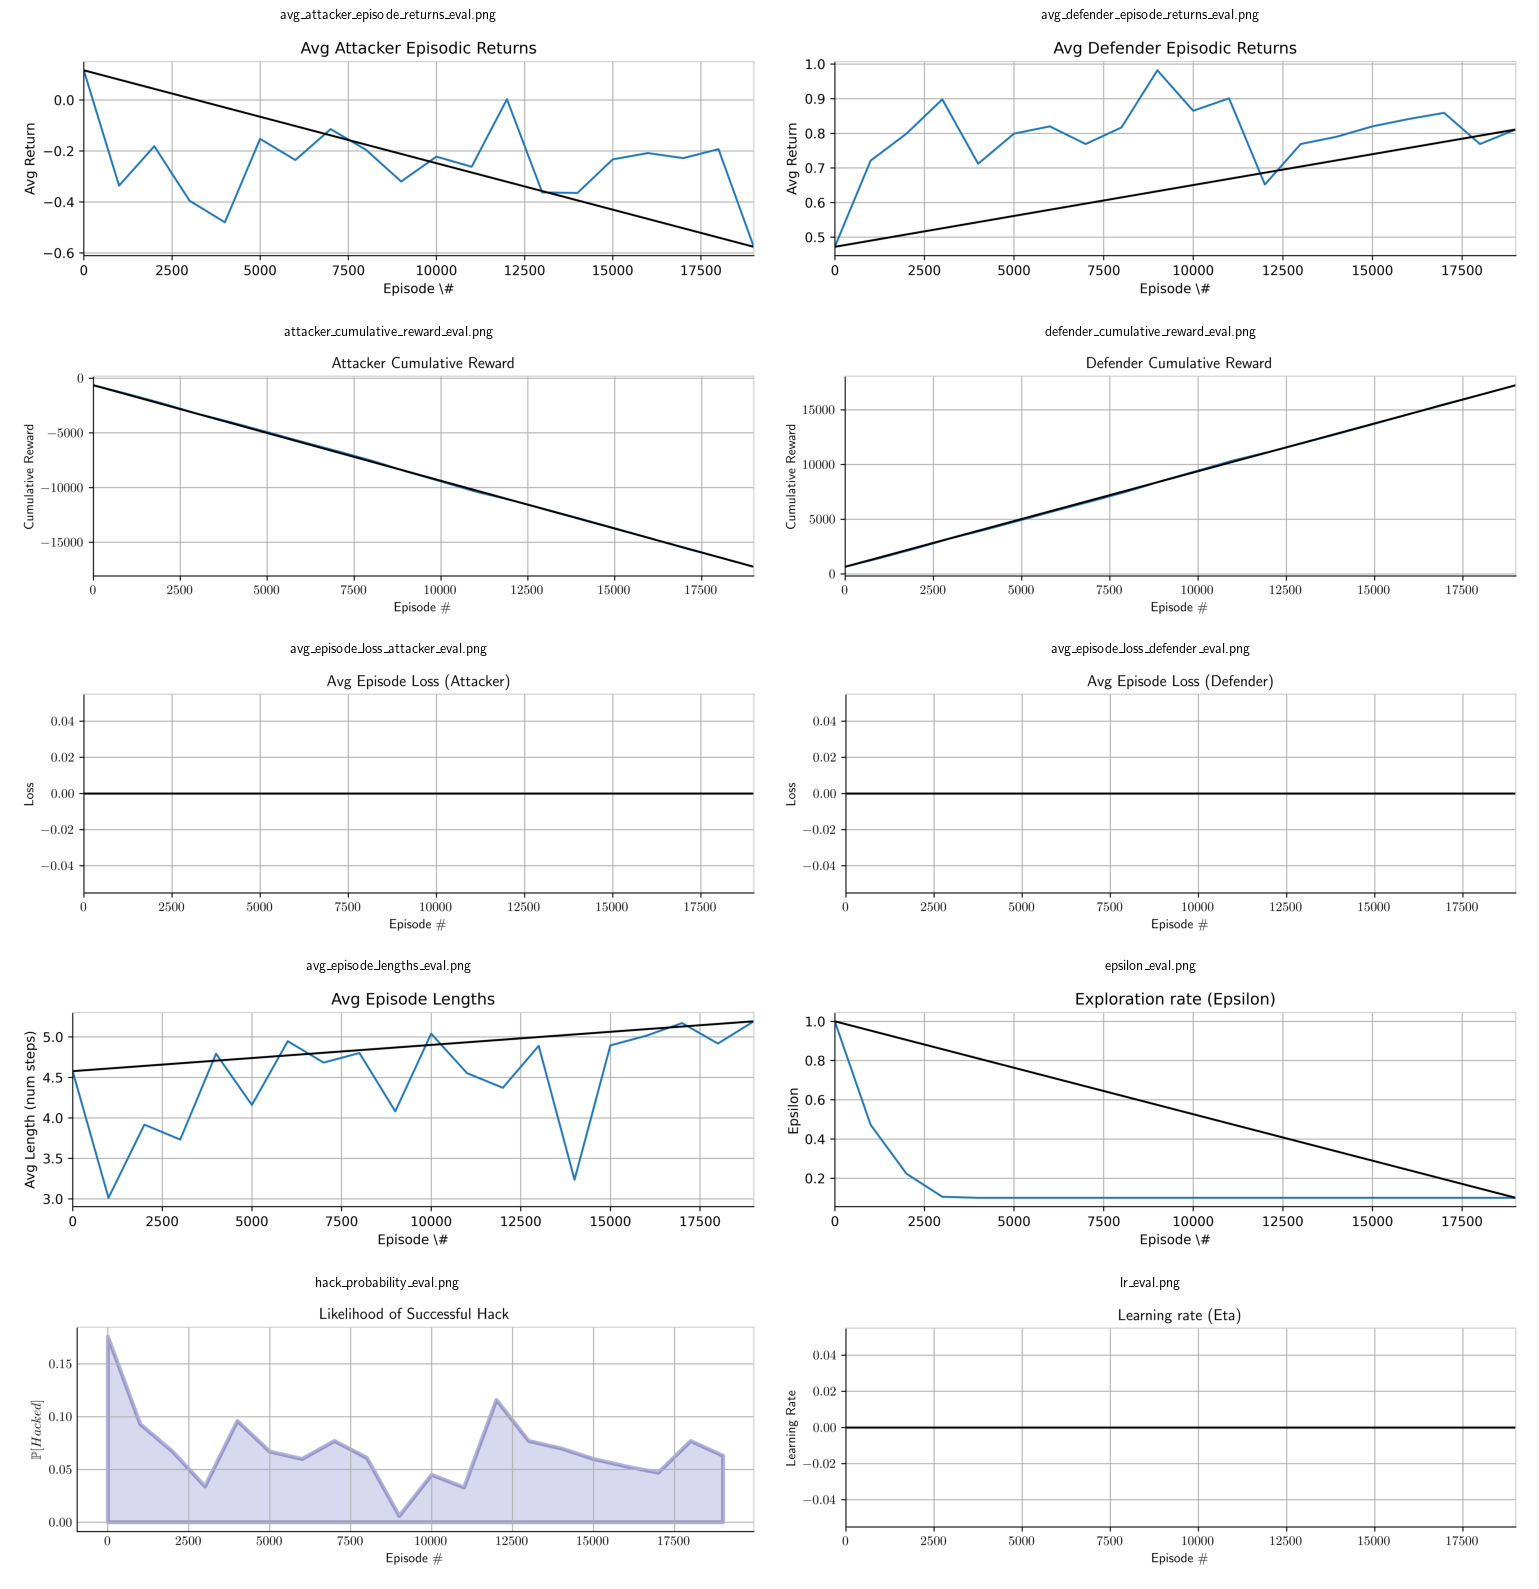

In [51]:
plot_experiment(Algorithm.DDQN, EnvType.RANDOM, ddqn_ra_config, ddqn_ra_agent.eval_result, figsize=(16, 16))

## MaximalAttack

### Environment setup and training
Setup and run the MaximalAttack environment with DDQN. <br>
Hyperparameters chosen here are the same as the ones for RandomAttack.

In [13]:
ddqn_ma_output = {
    Artefact.TRAINING: create_artefact_dirs(Algorithm.DDQN, EnvType.MAXIMAL, Artefact.TRAINING),
    Artefact.TABLE: create_artefact_dirs(Algorithm.DDQN, EnvType.MAXIMAL, Artefact.TABLE),
    Artefact.PLOTS: create_artefact_dirs(Algorithm.DDQN, EnvType.MAXIMAL, Artefact.PLOTS),
}

ddqn_ma_env = IdsGameMaximalAttackV8EnvFixed(None, save_dir=ddqn_ma_output[Artefact.TRAINING])

ddqn_ma_config = QAgentConfig(
    gamma=0.98,               # Discount factor
    alpha=0.001,              # Learning rate
    epsilon=1,                # Initial exploration rate
    min_epsilon=0.1,          # Minimum exploration rate
    epsilon_decay=0.99925,      # Decay rate per episode

    # Training parameters
    num_episodes=20000,
    train_log_frequency=1000,
    eval_log_frequency=500,
    eval_frequency=1000,
    eval_episodes=1000,

    # Agent type
    attacker=False,
    defender=True,            # Sets this agent as Defender

    # Logging e savings
    save_dir=ddqn_ma_output[Artefact.TABLE],

    dqn_config = ddqn_config,
)

ddqn_ma_agent = DDQNAgent(ddqn_ma_env, ddqn_ma_config)
ddqn_ma_agent.train()

[Warmup] step:0, buffer_size: 0:   0%|          | 0/10000 [00:00<?, ?it/s]/tmp/ipython-input-11-3387873866.py:818: RuntimeWarning: invalid value encountered in divide
  attacker_obs_1 = attacker_obs[:, 0:-1] / np.linalg.norm(attacker_obs[:, 0:-1])
[Warmup] step:9000, buffer_size: 9000: 100%|██████████| 10000/10000 [00:10<00:00, 918.44it/s]
[Train] epsilon:1.00,avg_a_R:0.00,avg_d_R:0.00,avg_t:0.00,avg_h:0.00,acc_A_R:0.00,acc_D_R:0.00:   0%|          | 0/20000 [00:15<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/t

### Results
From the plots below we can see that the defender nearly reached +20k reward points and the attacker almost -20k. <br>
Hack probability almost reached 0%, indicating that the attacker had little to no chance in beating the defender in this environment.

Reading from ./output/ddqn/maximal/results/plots/0


[Train] episode: 19000.00 epsilon:0.10,avg_a_R:0.01,avg_d_R:0.83,avg_t:4.49,avg_h:0.06,acc_A_R:95.13,acc_D_R:15570.00,A_loss:nan,D_loss:0.005575,replay_s:97180,lr:7.46E-08,c_h:0.06: 100%|██████████| 20000/20000 [23:40<00:00, 20.04it/s]
[Eval] avg_a_R:0.00,avg_d_R:0.00,avg_t:0.00,avg_h:0.00,acc_A_R:0.00,acc_D_R:0.00: 100%|██████████| 1000/1000 [00:22<00:00, 85.15it/s]

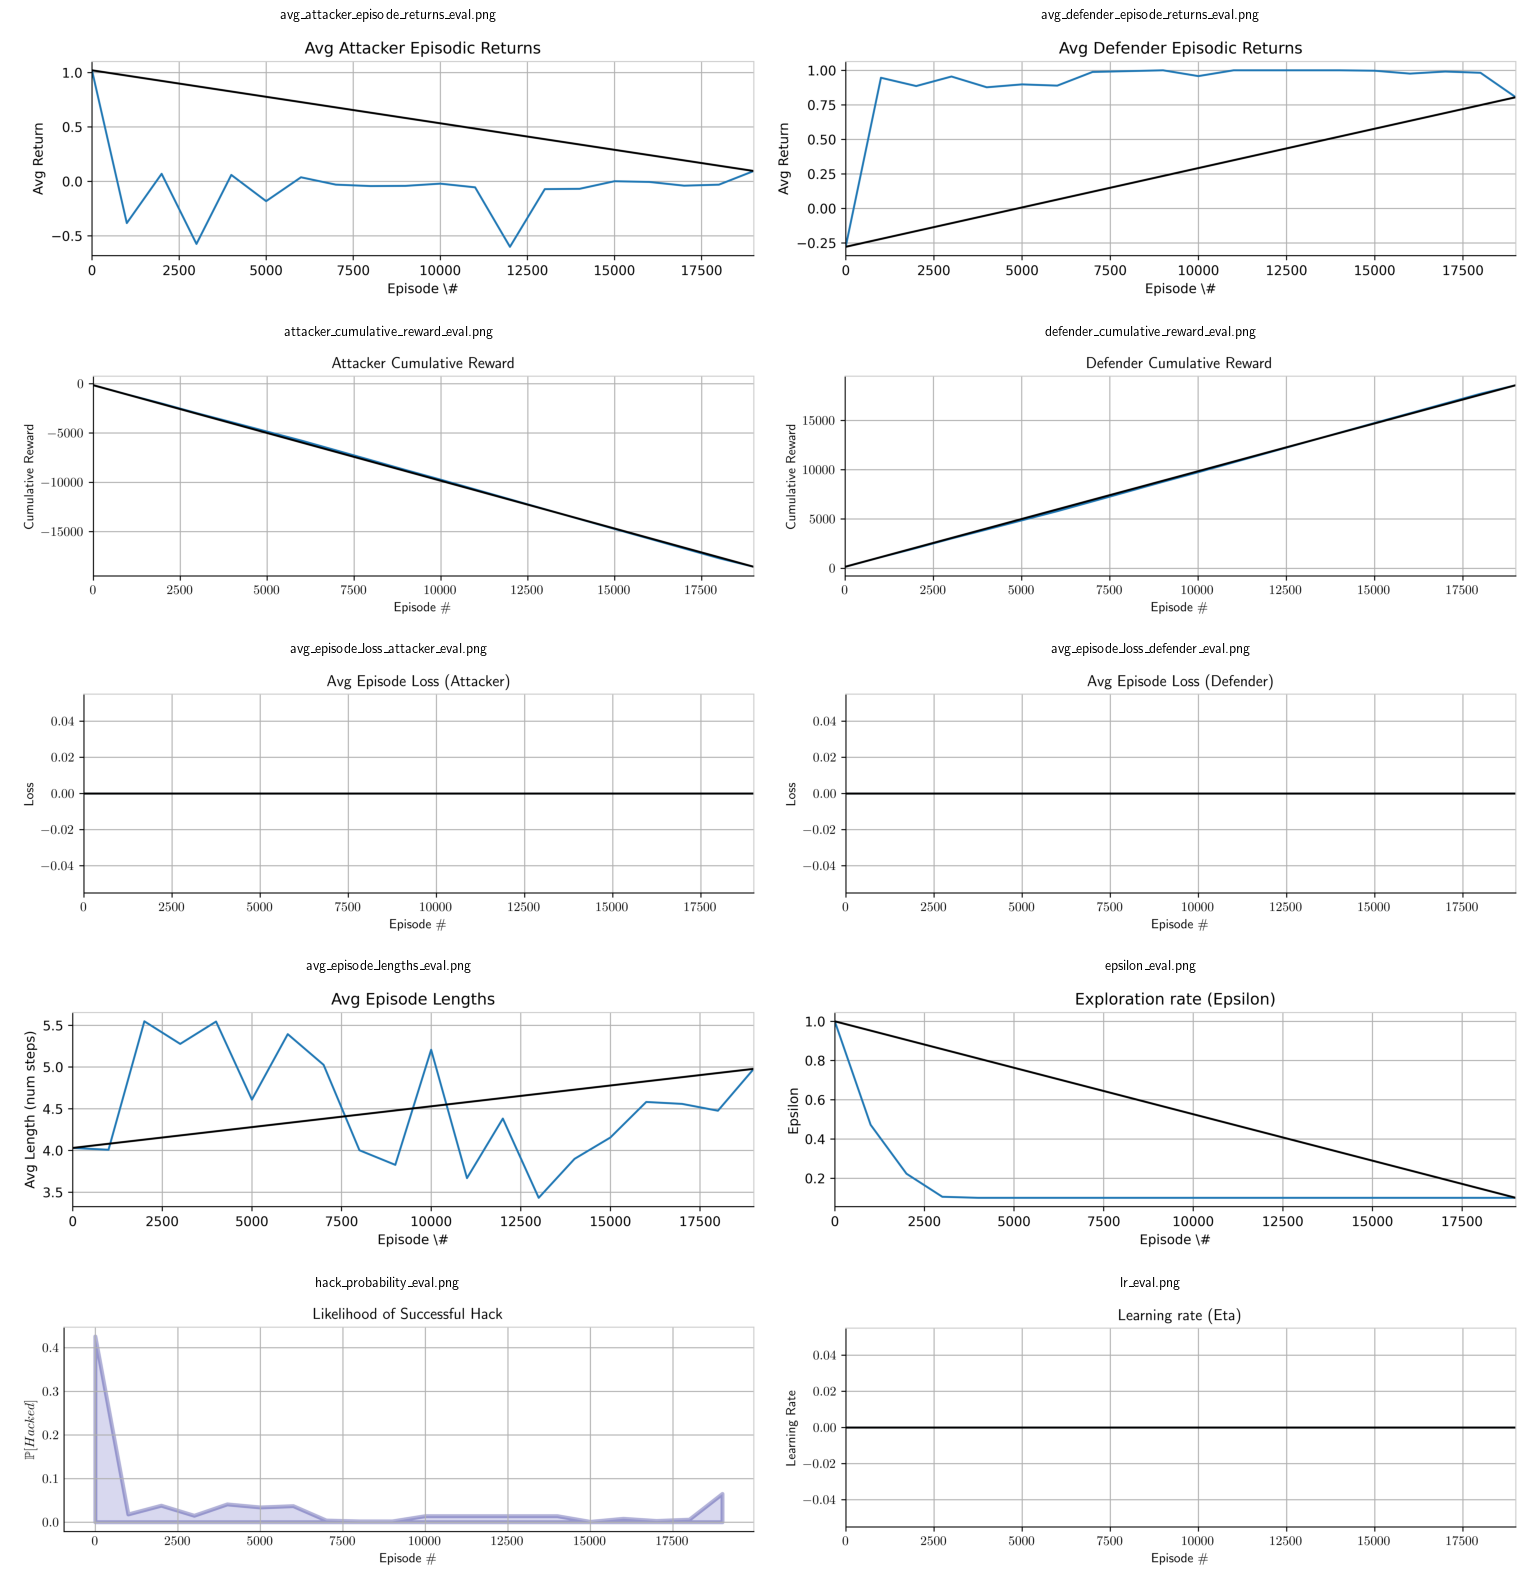

In [14]:
plot_experiment(Algorithm.DDQN, EnvType.MAXIMAL, ddqn_ma_config, ddqn_ma_agent.eval_result, figsize=(16, 16))

# Conclusion

We've trained 3 different algorithms and compared them against identical tasks. <br>
Each one of them have their pro and contras, which makes them more or less suitable for this particular problem. <br><br>

QLearning was the fastest to train on CPU, making it quite efficient in terms of resources. It shows promising results for our task, but the tabular approach might be limiting for more complex tasks.
<br><br>
SARSA, an on-policy adaptation of the off-policy QLearning algorithm, did not do well enough in the tests we've run. This might be either related to scarse exploration, sub-optimal hyperparameters, too short training or the on-policy method is not well suited for a randomized strategy and prefers a more deterministic one.
<br><br>
Lastly, Double DQN, a Deep Neural Network based QLearning implementation with 2 models, was the slowest and most resource intensive to train. On CPU, 20k episodes required 20-30 minutes to be trained. Regardless of the resource requirements, DDQN managed to outperform all other algorithms that were tested, bringing the hack probability for both environments between 0 - 7% and a steady increase in rewards for the defender (and a steady decrease for the attacker).
